# Function Declarations

Run once

In [1]:
from fairness_metric_utils import *
from penalty_utils import *
from weight_utils import *

In [2]:
def prepare_dataframe_for_attribute(dataset_path, attribute):
    """
    Load and prepare dataframe with specified attribute column.
    
    For combined attributes (e.g., 'sex-race'), creates the combined column 
    by concatenating individual attribute values and drops the individual columns.
    For single attributes, returns the dataframe as-is.
    
    Args:
        dataset_path: Path to the CSV file
        attribute: Single attribute (e.g., 'sex') or combined (e.g., 'sex-race')
    
    Returns:
        DataFrame with the attribute column prepared
    """
    df = pd.read_csv(dataset_path)
    
    # Check if this is a combined attribute
    individual_attrs = attribute.split('-')
    
    if len(individual_attrs) > 1:
        # Create combined column by concatenating individual attributes
        df[attribute] = reduce(
            lambda x, y: x.astype(str) + y.astype(str), 
            [df[col] for col in individual_attrs]
        )
        # Drop the individual attribute columns
        df = df.drop(columns=individual_attrs)
    
    return df

Select ONCE, the sensitive attribute for the rest of the dataset (WIP)

## Plot Confusion Matrix

In [3]:
def plot_confusion_matrix(cm_data, forwhat='', sensible_attribute='', mapping={}):

    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    # Create figure with subplots for each subgroup
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Confusion Matrices by Subgroup: {sensible_attribute} {forwhat}', fontsize=16, fontweight='bold')

    # Flatten axes for easier iteration
    axes = axes.flatten()

    # Subgroups and their decoded labels
    subgroups = ['00', '01', '10', '11']
    individual_attrs = sensible_attribute.split('-')

    # Iterate through subgroups
    for idx, group in enumerate(subgroups):
        ax = axes[idx]
        
        if group in cm_data:
            cm = cm_data[group]
            
            # Create heatmap with counts
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                        cbar_kws={'label': 'Count'}, vmin=0,
                        xticklabels=['Pred Neg', 'Pred Pos'],
                        yticklabels=['True Neg', 'True Pos'])
            
            # Decode group label
            attr1_val = mapping[individual_attrs[0]][int(group[0])]
            attr2_val = mapping[individual_attrs[1]][int(group[1])]
            
            # Calculate metrics for subtitle
            tn, fp, fn, tp = cm.ravel()
            total = tn + fp + fn + tp
            
            # Add text labels (TN, FP, FN, TP) on each cell
            labels = [['TN', 'FP'], ['FN', 'TP']]
            for i in range(2):
                for j in range(2):
                    text = ax.text(j + 0.5, i + 0.3, labels[i][j],
                                 ha='center', va='center',
                                 color='darkred', fontsize=7, fontweight='bold')
            
            # Title with decoded labels and sample count
            ax.set_title(f'Group {group}: {attr1_val} & {attr2_val}\n' + 
                        f'N = {total}',
                        fontweight='bold', fontsize=11)
            ax.set_xlabel('Predicted Label', fontsize=10)
            ax.set_ylabel('True Label', fontsize=10)
        else:
            # Handle missing subgroups
            ax.text(0.5, 0.5, f'Group {group}\nNo Data', 
                ha='center', va='center', fontsize=14, transform=ax.transAxes)
            ax.axis('off')

    plt.tight_layout()
    plt.show()

## Weights Functions



### $w_i = 1 + \lambda * Penalty(g_i) $

In [4]:
# df = prepare_dataframe_for_attribute(dataset_path, sensible_attribute)

In [5]:
def compute_weights_notsized(lambda_=5.0, m='FPN', penalties_onval=None, X_train=None, sensible_attribute=None):
    train_df = X_train[sensible_attribute].copy()
    weights_for_training = np.ones(len(train_df))
    # lambda_ = 10.0
    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100))
        for group, penalty in penalties_onval[m].items()
    }


    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row[sensible_attribute]
        if group in group_weights:
            weights_for_training[i] = group_weights[group]

    print(f"Training samples: {len(weights_for_training)}, Unique weights per group: {group_weights}")
    weights_notsized = weights_for_training

    return weights_notsized


### $w_i = 1 + \lambda * Penalty(g_i) * \frac{|g_i|}{|G_{max}|} $

In [6]:
# df = prepare_dataframe_for_attribute(dataset_path, sensible_attribute)

In [7]:
def compute_weights_sized(lambda_=1.0, m='PPE', penalties_onval=None, X_train=None, sensible_attribute=None):

    train_df = X_train[sensible_attribute].copy()
    weights_for_training = np.ones(len(train_df))

    # # Calculate average weight per group from validation set
    # df['weight'] = weights
    group_counts2 = train_df[sensible_attribute].value_counts().to_dict() # |g_i| number of attribute value combinations for subgroup "group_col"
    max_group_size = max(group_counts2.values()) # |G_max| subgroup with the highest number of attribute value combinations (dimension)

    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100) * (group_counts2.get(group, 1)/max_group_size))
        for group, penalty in penalties_onval[m].items()
    }


    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row[sensible_attribute]
        if group in group_weights:
            weights_for_training[i] = group_weights[group]

    print(f"Training samples: {len(weights_for_training)}, Unique weights per group: {group_weights}")
    weights_sized = weights_for_training

    return weights_sized

---

## Model 2: Fairness metrics and penalty after reweighting

## Function

To compute penalties for Model 2:
- **Actual value**: Fairness metric for `sex-race` using Model 2's predictions
- **Predicted value**: Harmonic mean of `sex` and `race` metrics using Model 2's predictions

**Weights were computed on validation set, then propagated to the training set based on group membership.** 

**Now we fit the model on training set with these weights and evaluate on test set.**

In [8]:
def compute_penalties_after_reweighting(weights, fairness_metric, dataset_path, sensible_attribute, X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels, random_seed=None):
    # Train Model 2 ONLY on the combined attribute (sensible_attribute) with weights
    import xgboost as xgb
    attributes = sensible_attribute.split('-') + [sensible_attribute]
    fairness_metrics_dict_test_reweighed = {}

    for attribute in attributes:        
        df = prepare_dataframe_for_attribute(dataset_path, attribute)
        
        # Convert string combinations to numeric codes for XGBoost
        X_train_numeric = X_train[attribute].copy()
        X_train_numeric[attribute] = X_train_numeric[attribute].astype('category').cat.codes
        
        X_test_numeric = X_test[attribute].copy()
        X_test_numeric[attribute] = X_test_numeric[attribute].astype('category').cat.codes
        
        # Train model with weights on combined attribute
        model_reweighed = xgb.XGBClassifier(random_state=random_seed, eval_metric='logloss')
        model_reweighed.fit(X_train_numeric, y_train[attribute], sample_weight=weights)
        
        # Predict on test set
        y_pred_test_reweighed_combined = model_reweighed.predict(X_test_numeric)

        cm = confusion_matrix(y_test[attribute], y_pred_test_reweighed_combined, labels=target_variable_labels)
        
        # Compute sensible_indexes_test FRESH for this specific attribute
        sensible_indexes_test_attr = df[attribute].loc[list(X_test[attribute].index)]
        
        # Compute FAIRNESS METRICS for each attribute on TEST set
        # Use the SAME predictions (from combined attribute) for all attributes
        fairness_metrics_dict_test_reweighed[attribute], group_counts_test_reweighed, cm_dict_test_reweighed = \
        get_fairness_metrics(df, attribute, sensible_indexes_test_attr, \
        y_pred_test_reweighed_combined, y_test[attribute], X_test[attribute], \
        fair_metrics, dataset_path, mapping, target_variable_labels=['0', '1'])

    individual_attributes = sensible_attribute.split('-')
    df_original = pd.read_csv(dataset_path)

    penalties_ontest_reweighed_harmonic, penalties_ontest_reweighed_geometric, penalties_ontest_reweighed_arithmetic = \
    compute_penalty_2(fairness_metrics_dict_test_reweighed, df_original, individual_attributes[0], individual_attributes[1], fairness_metric)

    return penalties_ontest_reweighed_harmonic

In [9]:
def performance_after_reweighting(weights, sensible_attribute, X_train, y_train, X_test, y_test, random_seed=None): 
    import xgboost as xgb
    
    # Convert string combinations to numeric codes for XGBoost
    X_train_numeric = X_train[sensible_attribute].copy()
    X_train_numeric[sensible_attribute] = X_train_numeric[sensible_attribute].astype('category').cat.codes
    
    X_test_numeric = X_test[sensible_attribute].copy()
    X_test_numeric[sensible_attribute] = X_test_numeric[sensible_attribute].astype('category').cat.codes
    
    # Train model with weights on combined attribute
    model_reweighed = xgb.XGBClassifier(random_state=random_seed, eval_metric='logloss')
    model_reweighed.fit(X_train_numeric, y_train[sensible_attribute], sample_weight=weights)
    
    # Predict on test set
    y_pred_test_reweighed_combined = model_reweighed.predict(X_test_numeric)

    perf_metrics = performance_metrics(y_test[sensible_attribute], y_pred_test_reweighed_combined)
    
    return perf_metrics


### Plots

In [10]:
import matplotlib.pyplot as plt
import numpy as np

def plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, sensible_attribute, mapping, lambd):
    """
    Generalized version that works with any subgroup combination.
    
    Args:
        fair_metrics: List of fairness metrics to plot
        penalties_ontest: Dictionary of penalties before reweighting {metric: {subgroup: penalty}}
        penalties_ontest_after_reweighting: Dictionary of penalties after reweighting
        sensible_attribute: String like 'age-edu', 'sex-race', etc.
        mapping: Dictionary mapping attribute codes to labels
    """
    # Extract subgroups (assuming all metrics have the same subgroups)
    subgroups = list(penalties_ontest[fair_metrics[0]].keys())
    
    # Parse the sensible_attribute to get individual attributes
    individual_attrs = sensible_attribute.split('-')
    
    # Set up the plot
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    axes = axes.flatten()

    # Create a bar plot for each metric
    for idx, metric in enumerate(fair_metrics):
        ax = axes[idx]
        
        # Extract penalties before and after for this metric
        penalties_before = [penalties_ontest[metric].get(group, 0) for group in subgroups]
        penalties_after = [penalties_ontest_after_reweighting[metric].get(group, 0) for group in subgroups]
        
        # Set up bar positions
        x = np.arange(len(subgroups))
        width = 0.35
        
        # Create bars
        bars1 = ax.bar(x - width/2, penalties_before, width, label='Before Reweighting', alpha=0.8, color='#e74c3c')
        bars2 = ax.bar(x + width/2, penalties_after, width, label='After Reweighting', alpha=0.8, color='#3498db')
        
        # Customize plot
        ax.set_xlabel('Subgroup', fontsize=10, fontweight='bold')
        ax.set_ylabel('Penalty (%)', fontsize=10, fontweight='bold')
        ax.set_title(f'{metric} Penalty Comparison', fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        
        # Decode subgroup labels dynamically based on sensible_attribute
        decoded_labels = []
        for group in subgroups:
            # Decode each character in the group code using corresponding attribute
            decoded_parts = []
            for i, attr in enumerate(individual_attrs):
                attr_code = int(group[i])
                attr_label = mapping[attr][attr_code]
                decoded_parts.append(attr_label)
            
            # Join with newline for multi-line labels
            decoded_labels.append('\n'.join(decoded_parts))
        
        ax.set_xticklabels(decoded_labels, fontsize=8)
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

    # Remove extra subplots if any
    for idx in range(len(fair_metrics), len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.suptitle(f'Penalty Comparison: Before vs After Reweighting\nSubgroup: {sensible_attribute}, λ: {lambd}', 
                fontsize=16, fontweight='bold', y=1.03)
    plt.show()

In [11]:
# Individual plots for each metric (larger view for detailed inspection)
def plot_penalty_comparison_all_individual(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, sensible_attribute, mapping, lambd):
    subgroups = list(penalties_ontest[fair_metrics[0]].keys())

    for metric in fair_metrics:
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        
        # Extract penalties before and after for this metric
        penalties_before = [penalties_ontest[metric].get(group, 0) for group in subgroups]
        penalties_after = [penalties_ontest_after_reweighting[metric].get(group, 0) for group in subgroups]
        
        # Set up bar positions
        x = np.arange(len(subgroups))
        width = 0.35
        
        # Create bars
        bars1 = ax.bar(x - width/2, penalties_before, width, label='Before Reweighting', alpha=0.8, color='#e74c3c')
        bars2 = ax.bar(x + width/2, penalties_after, width, label='After Reweighting', alpha=0.8, color='#3498db')
        
        # Add value labels on bars
        for bar in bars1:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)
        
        for bar in bars2:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)
        
        individual_attrs = sensible_attribute.split('-')
        # Decode subgroup labels dynamically based on sensible_attribute
        decoded_labels = []
        for group in subgroups:
            # Decode each character in the group code using corresponding attribute
            decoded_parts = []
            for i, attr in enumerate(individual_attrs):
                attr_code = int(group[i])
                attr_label = mapping[attr][attr_code]
                decoded_parts.append(attr_label)
            
            # Join with newline for multi-line labels
            decoded_labels.append('\n'.join(decoded_parts))
       
        
        # Customize plot
        ax.set_xlabel('Subgroup', fontsize=12, fontweight='bold')
        ax.set_ylabel('Penalty (%)', fontsize=12, fontweight='bold')
        ax.set_title(f'{metric} Penalty Comparison, λ: {lambd}', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(decoded_labels, fontsize=10)
        ax.legend(fontsize=11, loc='best')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
        
        plt.tight_layout()
        plt.show()
        print(f"\n{metric} - Penalty Changes:")
        for i, group in enumerate(subgroups):
            before = penalties_before[i]
            after = penalties_after[i]
            change = after - before
            print(f"  {decoded_labels[i].replace(chr(10), '-')}: {before:.2f} → {after:.2f} (Δ = {change:+.2f})")
        print("-" * 60)

In [12]:
def plot_penalty_comparison_lambdas(fairness_metric, lambdas, penalties_ontest, penalties_after_by_lambda, sensible_attribute, mapping):
    """
    Plot penalty comparison across different lambda values for a single fairness metric.
    
    Args:
        fairness_metric: Single fairness metric to plot (e.g., 'FPN')
        lambdas: List of lambda values
        penalties_ontest: Dictionary of penalties before reweighting {metric: {subgroup: penalty}}
        penalties_after_by_lambda: Dictionary mapping lambda to penalties after reweighting
                                  {lambda: {metric: {subgroup: penalty}}}
        sensible_attribute: String like 'age-edu', 'sex-race', etc.
        mapping: Dictionary mapping attribute codes to labels
    """
    # Extract subgroups
    subgroups = list(penalties_ontest[fairness_metric].keys())
    
    # Parse the sensible_attribute to get individual attributes
    individual_attrs = sensible_attribute.split('-')
    
    # Determine grid size based on number of lambdas
    n_lambdas = len(lambdas)
    if n_lambdas <= 3:
        nrows, ncols = 1, n_lambdas
    elif n_lambdas <= 6:
        nrows, ncols = 2, 3
    elif n_lambdas <= 9:
        nrows, ncols = 3, 3
    else:
        nrows, ncols = 3, 4
    
    # Set up the plot
    fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 5*nrows))
    if n_lambdas == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if n_lambdas > 1 else [axes]
    
    # Get penalties before reweighting (same for all lambdas)
    penalties_before = [penalties_ontest[fairness_metric].get(group, 0) for group in subgroups]
    
    # Create a bar plot for each lambda
    for idx, lambd in enumerate(lambdas):
        ax = axes[idx]
        
        # Extract penalties after for this lambda
        penalties_after = [penalties_after_by_lambda[lambd][fairness_metric].get(group, 0) for group in subgroups]
        
        # Set up bar positions
        x = np.arange(len(subgroups))
        width = 0.35
        
        # Create bars
        bars1 = ax.bar(x - width/2, penalties_before, width, label='Before Reweighting', alpha=0.8, color='#e74c3c')
        bars2 = ax.bar(x + width/2, penalties_after, width, label='After Reweighting', alpha=0.8, color='#3498db')
        
        # Add value labels on bars
        for bar in bars1:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)
        
        for bar in bars2:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)
        
        # Customize plot
        ax.set_xlabel('Subgroup', fontsize=10, fontweight='bold')
        ax.set_ylabel('Penalty (%)', fontsize=10, fontweight='bold')
        ax.set_title(f'λ = {lambd}', fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        
        # Decode subgroup labels dynamically
        decoded_labels = []
        for group in subgroups:
            decoded_parts = []
            for i, attr in enumerate(individual_attrs):
                attr_code = int(group[i])
                attr_label = mapping[attr][attr_code]
                decoded_parts.append(attr_label)
            decoded_labels.append('\n'.join(decoded_parts))
        
        ax.set_xticklabels(decoded_labels, fontsize=8)
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    
    # Remove extra subplots if any
    for idx in range(n_lambdas, len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.suptitle(f'Penalty Comparison Across Lambda Values\nMetric: {fairness_metric}, Subgroup: {sensible_attribute}', 
                fontsize=16, fontweight='bold', y=1.09)
    plt.show()

# Experiment Runs

# Iteration Configuration

Set the number of iterations for randomized experiments

In [13]:
# Number of iterations for randomized experiments
N_ITERATIONS = 10  # Start with 10, can increase to 30-50 for final results

print(f"Running {N_ITERATIONS} iterations with randomized model seeds")

Running 10 iterations with randomized model seeds


## Result Storage Structure

Dictionaries to store results from each iteration

In [14]:
from collections import defaultdict
import copy

# Storage for all iterations
all_iterations_results = {
    'performance_val': [],
    'performance_test': [],
    'performance_after': [],
    'fairness_metrics_val': [],
    'fairness_metrics_test': [],
    'penalties_val': [],
    'penalties_test': [],
    'penalties_after': [],
}

print("Result storage initialized")

Result storage initialized


## Aggregation Functions

Functions to compute mean, std, median across iterations

In [15]:
def aggregate_results(results_list):
    """
    Takes a list of dictionaries and returns mean, std, median.
    Handles nested structures (e.g., metrics per subgroup).
    
    Args:
        results_list: List of dictionaries with same structure
    
    Returns:
        Dictionary with aggregated statistics
    """
    if len(results_list) == 0:
        return {}
    
    # Check if results are dictionaries or simple values
    if isinstance(results_list[0], dict):
        aggregated = {}
        for key in results_list[0].keys():
            values = [r[key] for r in results_list if key in r]
            
            # Recursive for nested dicts
            if len(values) > 0 and isinstance(values[0], dict):
                aggregated[key] = aggregate_results(values)
            elif len(values) > 0:
                # Aggregate numeric values
                values_array = np.array(values)
                aggregated[key] = {
                    'mean': float(np.mean(values_array)),
                    'std': float(np.std(values_array)),
                    'median': float(np.median(values_array)),
                    'min': float(np.min(values_array)),
                    'max': float(np.max(values_array)),
                    'values': values  # Keep raw values for further analysis
                }
        return aggregated
    else:
        # Simple list of values
        values_array = np.array(results_list)
        return {
            'mean': float(np.mean(values_array)),
            'std': float(np.std(values_array)),
            'median': float(np.median(values_array)),
            'min': float(np.min(values_array)),
            'max': float(np.max(values_array)),
            'values': results_list
        }

print("Aggregation function defined")

Aggregation function defined


In [16]:
def format_aggregated_results(aggregated_data, title="Aggregated Results"):
    """
    Pretty print aggregated results showing mean ± std.
    
    Args:
        aggregated_data: Dictionary with aggregated statistics
        title: Title for the output
    """
    import pandas as pd
    
    print(f"\n{'='*60}")
    print(f"{title}")
    print(f"{'='*60}\n")
    
    def print_recursive(data, indent=0):
        prefix = "  " * indent
        if isinstance(data, dict):
            if 'mean' in data and 'std' in data:
                # This is a leaf node with statistics
                print(f"{prefix}Mean: {data['mean']:.4f} ± {data['std']:.4f}")
                print(f"{prefix}Median: {data['median']:.4f}, Range: [{data['min']:.4f}, {data['max']:.4f}]")
            else:
                # This is a nested structure
                for key, value in data.items():
                    print(f"{prefix}{key}:")
                    print_recursive(value, indent + 1)
    
    print_recursive(aggregated_data)
    print(f"\n{'='*60}\n")

print("Display helper function defined")

Display helper function defined


# ADULT CENSUS

## Parameters

Made so they can be easily changed

In [17]:
# Flags
ALL_FM_L_NOTSIZED = 0  # Set to 1 to plot all fairness metrics specified in 'fair_metrics' for all lambdas in 'lambdas' when using notsized weights
SIZED = 0 # Set to 1 to add plots using sized weights
ALL_FM_L_SIZED = 0  # Set to 1 to plot all fairness metrics specified in 'fair_metrics' for all lambdas in 'lambdas' when using sized weights

In [18]:
datasets = {0: 'AdultCensus/adult-preprocessed-2race-2age-2edu.csv', 
            1: '/COMPAS/compas-preprocessed-binary.csv', 
            2: '/GermanCredit/german-preprocessed-binary.csv'}

dataset_path = datasets[0]

In [19]:
sensible_attribute = 'sex-race'

In [20]:
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

def get_model(model_type='xgb', random_seed=None):
    """
    Factory function to create models with specified seed.
    
    Args:
        model_type: 'xgb', 'lgbm', or 'catboost'
        random_seed: Seed for reproducibility (None for random)
    
    Returns:
        Model instance
    """
    models = {
        'xgb': xgb.XGBClassifier(random_state=random_seed, eval_metric='logloss'),
        'lgbm': lgb.LGBMClassifier(random_state=random_seed, verbose=-1),
        'catboost': cb.CatBoostClassifier(random_state=random_seed, verbose=False)
    }
    return models[model_type]

# For compatibility with existing code (single run mode)
selected_model_type = 'xgb'
selected_model = get_model(selected_model_type, random_seed=1234)

In [21]:
# ['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']
fair_metrics = ['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']

In [22]:
lambdas = [0.5, 1.0, 2.0, 5.0, 10.0]

In [23]:
fixed_lambda = 5.0

In [24]:
attributes = sensible_attribute.split('-') + [sensible_attribute]
print(attributes)

['sex', 'race', 'sex-race']


In [25]:
import pandas as pd

df=pd.read_csv(dataset_path)

if dataset_path == datasets[0]:  # Adult Census
    protected_attributes =['age', 'sex', 'race', 'edu']
    mapping= {
        'age':{
            0: 'young',
            1: 'adult'
        },
        'edu':{
            0: 'low-edu',
            1: 'high-edu'
        },
        'sex':{
            0: 'female',
            1: 'male'
        },
        'race':{
            0: 'Amer-Black-Other',
            1: 'Asian-White'
        }
    }
    feature_cols= df.columns
    target_variable = 'income'
elif dataset_path == datasets[1]:  # COMPAS
    protected_attributes =['age', 'sex', 'race']
    mapping= {
        'age':{
            0: 'age<35',
            1: 'age>35',
        },
        'sex':{
            0: 'fem',
            1: 'mal'
        },
        'race':{
            0: 'African',
            1: 'AsiaWhiHispNatOth'
        }
    }
    feature_cols= df.columns
    target_variable = 'is_violent_recid'
elif dataset_path == datasets[2]:  # German Credit
    protected_attributes =['age', 'sex']
    mapping= {
        'age':{
            0: 'young',
            1: 'adult'
        },
        'sex':{
            0: 'female',
            1: 'male'
        }
    }
    feature_cols= df.columns
    target_variable = 'risk'

target_variable_labels= ['0','1']
df.head()

,age,edu,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,1,0,6,1,1,0,0,4356,40,0
1,1,0,6,1,1,0,0,4356,18,0
2,1,1,6,4,0,0,0,4356,40,0
3,1,0,0,4,1,0,0,3900,40,0
4,1,1,5,3,1,0,0,3900,40,0


# Compute Fairness Metrics: Validation and Test

Using a model that predicts on validation set, and another that predicts on test set

In [26]:
# ============================================================================
# MAIN ITERATION LOOP
# ============================================================================
# This loop runs the entire pipeline N_ITERATIONS times with different random seeds

for iteration in range(N_ITERATIONS):
    print(f"\n{'='*70}")
    print(f"ITERATION {iteration + 1}/{N_ITERATIONS}")
    print(f"{'='*70}\n")
    
    # Set random seed for this iteration
    current_seed = iteration  # Use iteration number as seed for reproducibility
    
    # Create model for this iteration
    current_model = get_model(selected_model_type, random_seed=current_seed)
    
    # Data Split variables
    X_train = {}
    y_train = {}
    X_val = {}    # Validation set (used for computing fairness metrics, weights)
    y_val = {}
    X_test = {}   # Test set (unseen, used for final evaluation)
    y_test = {}

    # Validation set variables
    y_pred_val = {}   # Predictions on validation set
    fairness_metrics_dict_val= {}
    cm_val = {}
    cm_dict_val = {}
    group_counts_val = {}
    model_baseline_val = {}
    performance_metrics_val = {}

    # Test set variables
    y_pred_test = {}   # Predictions on test set
    fairness_metrics_dict_test= {}
    cm_test = {}
    cm_dict_test = {}
    group_counts_test = {}
    model_baseline_test = {}
    performance_metrics_test = {}

    for attribute in attributes:
        df = prepare_dataframe_for_attribute(dataset_path, attribute)

        # Compute DATA SPLIT for each attribute: TRAINING, VALIDATION, TEST
        sensible_indexes_val, sensible_indexes_test, X_train[attribute], y_train[attribute], X_val[attribute], y_val[attribute], X_test[attribute], y_test[attribute] = \
        compute_data_split(df, target_variable, attribute)

        # Compute MODEL PREDICTIONS for each attribute, on VALIDATION set | Model 1A
        y_pred_val[attribute], cm_val[attribute], model_baseline_val[attribute], performance_metrics_val[attribute] = \
        compute_model_predictions_general(X_train[attribute], y_train[attribute], X_val[attribute], y_val[attribute], \
                                  target_variable_labels, attribute, current_model)

        # Compute FAIRNESS METRICS for each attribute, on VALIDATION set
        fairness_metrics_dict_val[attribute], group_counts_val[attribute], cm_dict_val[attribute] = \
                                        get_fairness_metrics(df, attribute, sensible_indexes_val, \
                                        y_pred_val[attribute], y_val[attribute], X_val[attribute], \
                                        fair_metrics, dataset_path, mapping, target_variable_labels=['0','1'])
        
        # Compute MODEL PREDICTIONS for each attribute, on TEST set | Model 1B
        # Need to create a new model instance for test set
        current_model_test = get_model(selected_model_type, random_seed=current_seed)
        y_pred_test[attribute], cm_test[attribute], model_baseline_test[attribute], performance_metrics_test[attribute] = \
        compute_model_predictions_general(X_train[attribute], y_train[attribute], X_test[attribute], y_test[attribute], \
                                          target_variable_labels, attribute, current_model_test)

        # Compute FAIRNESS METRICS for each attribute, on TEST set
        fairness_metrics_dict_test[attribute], group_counts_test[attribute], cm_dict_test[attribute] = \
                                        get_fairness_metrics(df, attribute, sensible_indexes_test, \
                                        y_pred_test[attribute], y_test[attribute], X_test[attribute], \
                                        fair_metrics, dataset_path, mapping, target_variable_labels=['0', '1'])
    
    # Compute BASELINE penalties on TEST set and VAL set
    penalties_ontest = {}
    penalties_onval = {}
    df_original = pd.read_csv(dataset_path)
    individual_attributes = sensible_attribute.split('-')

    for m in fair_metrics:
        penalties_ontest_harmonic, penalties_ontest_geometric, penalties_ontest_arithmetic = \
        compute_penalty_2(fairness_metrics_dict_test, df_original, individual_attributes[0], individual_attributes[1], m)
        penalties_ontest[m] = penalties_ontest_harmonic

        penalties_onval_harmonic, penalties_onval_geometric, penalties_onval_arithmetic = \
        compute_penalty_2(fairness_metrics_dict_val, df_original, individual_attributes[0], individual_attributes[1], m)
        penalties_onval[m] = penalties_onval_harmonic
    
    # Compute performance after reweighting
    weights_notsized = compute_weights_notsized(fixed_lambda, 'FPN', penalties_onval, X_train, sensible_attribute)
    performance_metrics_after = performance_after_reweighting(weights_notsized, sensible_attribute, X_train, y_train, X_test, y_test, random_seed=current_seed)
    
    # Compute penalties after reweighting
    penalties_ontest_after_reweighting = {}
    for metric in fair_metrics:
        weights_notsized = compute_weights_notsized(fixed_lambda, metric, penalties_onval, X_train, sensible_attribute)
        penalties_ontest_after_reweighting[metric] = compute_penalties_after_reweighting(
            weights_notsized, metric, dataset_path, sensible_attribute, X_train, y_train, X_test, y_test, 
            fair_metrics, mapping, target_variable_labels, random_seed=current_seed
        )
    
    # Store results for this iteration
    all_iterations_results['performance_val'].append(copy.deepcopy(performance_metrics_val[sensible_attribute]))
    all_iterations_results['performance_test'].append(copy.deepcopy(performance_metrics_test[sensible_attribute]))
    all_iterations_results['performance_after'].append(copy.deepcopy(performance_metrics_after))
    all_iterations_results['fairness_metrics_val'].append(copy.deepcopy(fairness_metrics_dict_val))
    all_iterations_results['fairness_metrics_test'].append(copy.deepcopy(fairness_metrics_dict_test))
    all_iterations_results['penalties_val'].append(copy.deepcopy(penalties_onval))
    all_iterations_results['penalties_test'].append(copy.deepcopy(penalties_ontest))
    all_iterations_results['penalties_after'].append(copy.deepcopy(penalties_ontest_after_reweighting))
    
    print(f"Iteration {iteration + 1} completed successfully")

print(f"\n{'='*70}")
print(f"ALL {N_ITERATIONS} ITERATIONS COMPLETED")
print(f"{'='*70}\n")



ITERATION 1/10



sex
Precision: 0.7556935817805382, Recall: 0.6108786610878661, Accuracy: 0.8564701064701065, F1: 0.6756131420638594
{np.int64(0): array([[1448,   20],
       [  87,   94]]), np.int64(1): array([[2005,  216],
       [ 378,  636]])}
sex
Precision: 0.7752475247524753, Recall: 0.6492537313432836, Accuracy: 0.8669396110542477, F1: 0.7066787003610109
{np.int64(0): array([[1408,   22],
       [  91,   89]]), np.int64(1): array([[2044,  205],
       [ 332,  694]])}
race
Precision: 0.7556935817805382, Recall: 0.6108786610878661, Accuracy: 0.8564701064701065, F1: 0.6756131420638594
{np.int64(1): array([[2983,  228],
       [ 428,  701]]), np.int64(0): array([[470,   8],
       [ 37,  29]])}
race
Precision: 0.7752475247524753, Recall: 0.6492537313432836, Accuracy: 0.8669396110542477, F1: 0.7066787003610109
{np.int64(1): array([[2966,  219],
       [ 377,  753]]), np.int64(0): array([[486,   8],
       [ 46,  30]])}
sex-race
Precision: 0.7559958289885297, Recall: 0.606694560669456, Accuracy: 0.855

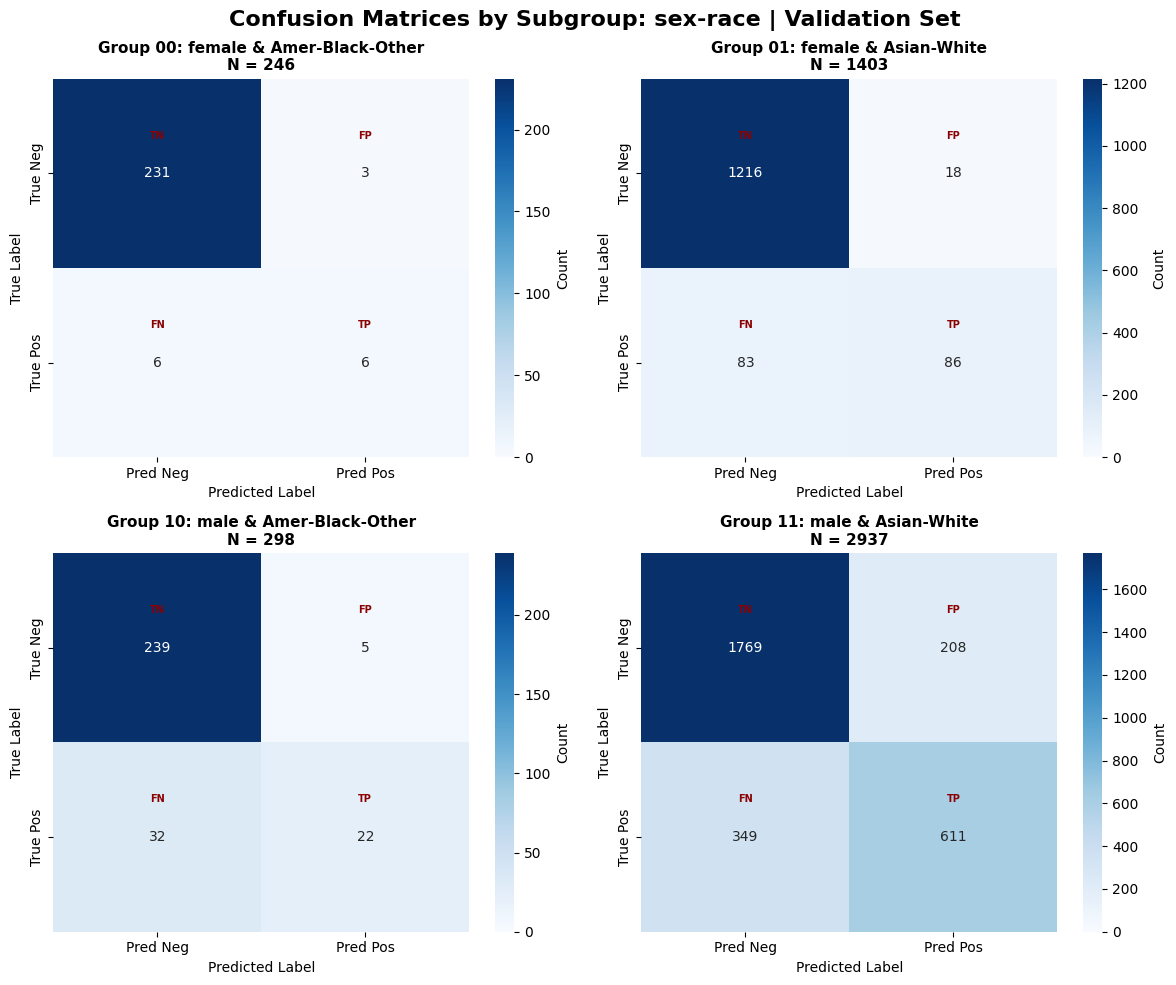

In [27]:
plot_confusion_matrix(cm_dict_val[sensible_attribute], '| Validation Set', sensible_attribute, mapping)

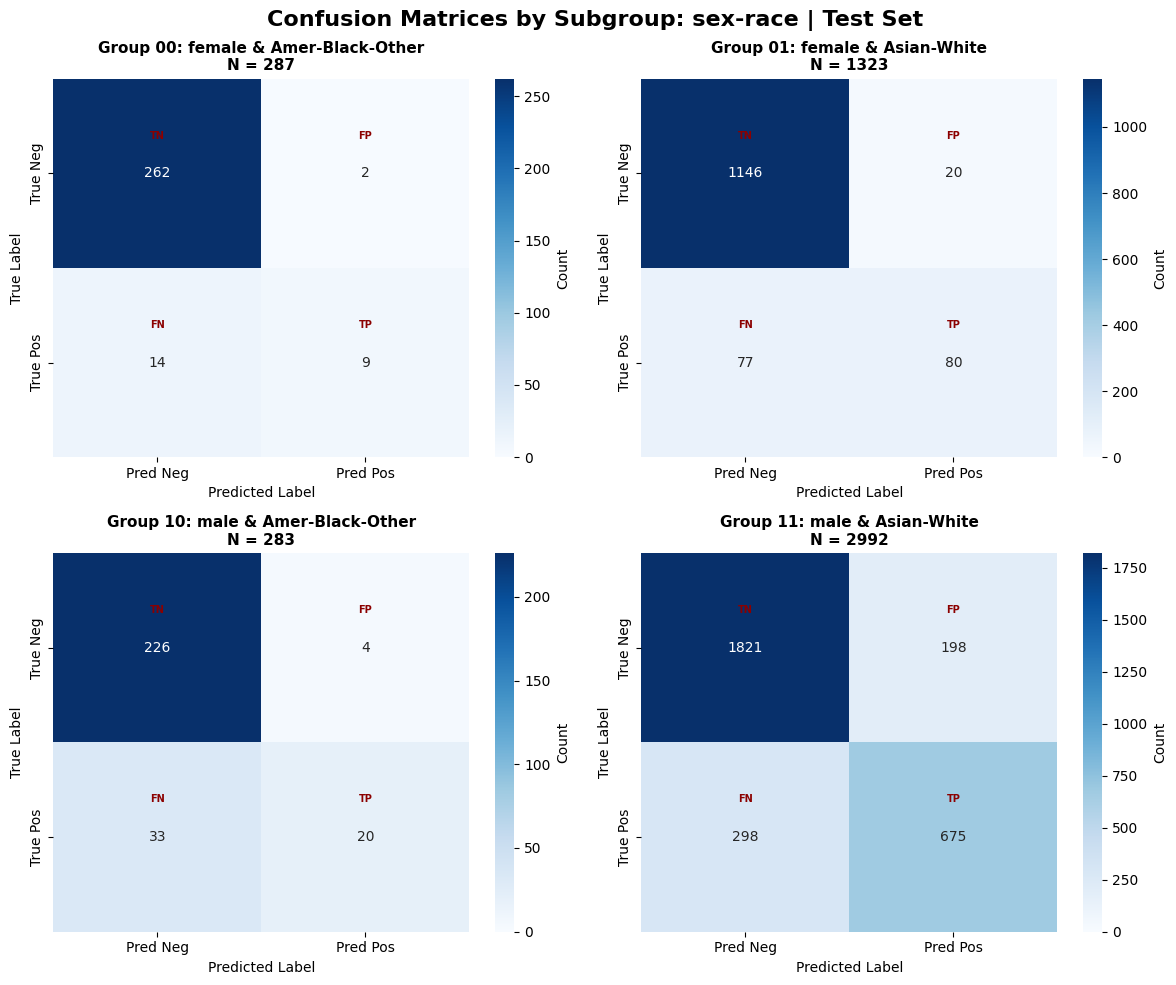

In [28]:
plot_confusion_matrix(cm_dict_test[sensible_attribute], '| Test Set', sensible_attribute, mapping)

# Aggregate Results Across Iterations

Compute mean, std, median for all metrics

In [29]:
# Aggregate all results
aggregated_results = {
    'performance_val': aggregate_results(all_iterations_results['performance_val']),
    'performance_test': aggregate_results(all_iterations_results['performance_test']),
    'performance_after': aggregate_results(all_iterations_results['performance_after']),
    'penalties_val': aggregate_results(all_iterations_results['penalties_val']),
    'penalties_test': aggregate_results(all_iterations_results['penalties_test']),
    'penalties_after': aggregate_results(all_iterations_results['penalties_after']),
}

print("✓ Results aggregated successfully")

✓ Results aggregated successfully


## Display Aggregated Performance Metrics

In [30]:
# Display performance metrics as a table
import pandas as pd

performance_data = []
for phase, phase_label in [('performance_test', 'Baseline (Test)'), ('performance_after', 'After Reweighting')]:
    for metric, values in aggregated_results[phase].items():
        performance_data.append({
            'Phase': phase_label,
            'Metric': metric,
            'Mean': f"{values['mean']:.4f}",
            'Std': f"{values['std']:.4f}",
            'Median': f"{values['median']:.4f}",
            'Range': f"[{values['min']:.4f}, {values['max']:.4f}]"
        })

df_performance = pd.DataFrame(performance_data)
print("\n" + "="*80)
print(f"PERFORMANCE METRICS ACROSS {N_ITERATIONS} ITERATIONS")
print("="*80)
print(df_performance.to_string(index=False))
print("="*80 + "\n")

TypeError: 'float' object is not subscriptable

## Display Aggregated Penalties

In [ ]:
# Display penalties for each metric and subgroup
print("\n" + "="*80)
print(f"PENALTIES ACROSS {N_ITERATIONS} ITERATIONS")
print("="*80 + "\n")

# Select a few key metrics to display
display_metrics = ['FPN', 'PPE', 'EOP']

for metric in display_metrics:
    if metric in aggregated_results['penalties_test']:
        print(f"\n{metric} Penalties:")
        print("-" * 80)
        
        penalty_data = []
        for subgroup in aggregated_results['penalties_test'][metric].keys():
            before = aggregated_results['penalties_test'][metric][subgroup]
            after = aggregated_results['penalties_after'][metric][subgroup]
            
            # Decode subgroup label
            individual_attrs = sensible_attribute.split('-')
            decoded_parts = []
            for i, attr in enumerate(individual_attrs):
                attr_code = int(subgroup[i])
                attr_label = mapping[attr][attr_code]
                decoded_parts.append(attr_label)
            decoded_label = '-'.join(decoded_parts)
            
            penalty_data.append({
                'Subgroup': decoded_label,
                'Before (Mean±Std)': f"{before['mean']:.2f}±{before['std']:.2f}",
                'After (Mean±Std)': f"{after['mean']:.2f}±{after['std']:.2f}",
                'Reduction': f"{before['mean'] - after['mean']:.2f}",
            })
        
        df_penalties = pd.DataFrame(penalty_data)
        print(df_penalties.to_string(index=False))
        print()

print("="*80 + "\n")

## Visualize Aggregated Penalties with Error Bars

In [ ]:
def plot_aggregated_penalties(aggregated_results, metrics_to_plot, sensible_attribute, mapping, fixed_lambda, n_iterations):
    """
    Plot aggregated penalties with error bars showing mean ± std.
    
    Args:
        aggregated_results: Dictionary with aggregated statistics
        metrics_to_plot: List of metrics to visualize  
        sensible_attribute: Combined attribute string
        mapping: Attribute decoding dictionary
        fixed_lambda: Lambda value used
        n_iterations: Number of iterations run
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    n_metrics = len(metrics_to_plot)
    if n_metrics <= 3:
        nrows, ncols = 1, n_metrics
        figsize = (7*n_metrics, 6)
    elif n_metrics <= 6:
        nrows, ncols = 2, 3
        figsize = (20, 12)
    else:
        nrows, ncols = 3, 4
        figsize = (20, 15)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    if n_metrics == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if n_metrics > 1 else [axes]
    
    individual_attrs = sensible_attribute.split('-')
    
    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx]
        
        if metric not in aggregated_results['penalties_test']:
            ax.text(0.5, 0.5, f'{metric}\nNo Data', ha='center', va='center', 
                   fontsize=14, transform=ax.transAxes)
            ax.axis('off')
            continue
        
        # Extract subgroups
        subgroups = list(aggregated_results['penalties_test'][metric].keys())
        
        # Decode labels
        decoded_labels = []
        for group in subgroups:
            decoded_parts = []
            for i, attr in enumerate(individual_attrs):
                attr_code = int(group[i])
                attr_label = mapping[attr][attr_code]
                decoded_parts.append(attr_label)
            decoded_labels.append('\n'.join(decoded_parts))
        
        # Extract means and stds
        before_means = [aggregated_results['penalties_test'][metric][g]['mean'] for g in subgroups]
        before_stds = [aggregated_results['penalties_test'][metric][g]['std'] for g in subgroups]
        after_means = [aggregated_results['penalties_after'][metric][g]['mean'] for g in subgroups]
        after_stds = [aggregated_results['penalties_after'][metric][g]['std'] for g in subgroups]
        
        # Plot
        x = np.arange(len(subgroups))
        width = 0.35
        
        bars1 = ax.bar(x - width/2, before_means, width, yerr=before_stds, 
                      label='Before Reweighting', alpha=0.8, color='#e74c3c',
                      capsize=5, error_kw={'linewidth': 2})
        bars2 = ax.bar(x + width/2, after_means, width, yerr=after_stds,
                      label='After Reweighting', alpha=0.8, color='#3498db',
                      capsize=5, error_kw={'linewidth': 2})
        
        # Customize
        ax.set_xlabel('Subgroup', fontsize=11, fontweight='bold')
        ax.set_ylabel('Penalty (%)', fontsize=11, fontweight='bold')
        ax.set_title(f'{metric} (n={n_iterations} iterations)', fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(decoded_labels, fontsize=9)
        ax.legend(fontsize=9)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    
    # Remove extra subplots
    for idx in range(len(metrics_to_plot), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.suptitle(f'Aggregated Penalty Comparison (λ={fixed_lambda}, {n_iterations} iterations)\\nError bars show ± 1 std dev', 
                fontsize=14, fontweight='bold', y=1.02)
    plt.show()

# Plot for key metrics
plot_aggregated_penalties(aggregated_results, ['FPN', 'PPE', 'EOP', 'FPR'], 
                          sensible_attribute, mapping, fixed_lambda, N_ITERATIONS)

## Save Aggregated Results

Save results for thesis reporting

In [ ]:
import pickle
import json
from datetime import datetime

# Create results directory if it doesn't exist
import os
os.makedirs('results/aggregated', exist_ok=True)

# Generate filename with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename_base = f"results/aggregated/{sensible_attribute}_{selected_model_type}_lambda{fixed_lambda}_n{N_ITERATIONS}_{timestamp}"

# Save as pickle (complete Python object)
with open(f"{filename_base}.pkl", 'wb') as f:
    pickle.dump({
        'aggregated_results': aggregated_results,
        'all_iterations_raw': all_iterations_results,
        'config': {
            'n_iterations': N_ITERATIONS,
            'lambda': fixed_lambda,
            'sensible_attribute': sensible_attribute,
            'model_type': selected_model_type,
            'dataset': dataset_path,
            'fair_metrics': fair_metrics,
        }
    }, f)

print(f"✓ Results saved to: {filename_base}.pkl")

# Also save a CSV summary for easy viewing
summary_data = []
for metric in ['FPN', 'PPE', 'EOP']:
    if metric in aggregated_results['penalties_test']:
        for subgroup in aggregated_results['penalties_test'][metric].keys():
            before = aggregated_results['penalties_test'][metric][subgroup]
            after = aggregated_results['penalties_after'][metric][subgroup]
            
            # Decode subgroup
            individual_attrs = sensible_attribute.split('-')
            decoded_parts = []
            for i, attr in enumerate(individual_attrs):
                attr_code = int(subgroup[i])
                attr_label = mapping[attr][attr_code]
                decoded_parts.append(attr_label)
            decoded_label = '-'.join(decoded_parts)
            
            summary_data.append({
                'Metric': metric,
                'Subgroup': decoded_label,
                'Penalty_Before_Mean': before['mean'],
                'Penalty_Before_Std': before['std'],
                'Penalty_After_Mean': after['mean'],
                'Penalty_After_Std': after['std'],
                'Reduction': before['mean'] - after['mean']
            })

df_summary = pd.DataFrame(summary_data)
df_summary.to_csv(f"{filename_base}_summary.csv", index=False)
print(f"✓ Summary saved to: {filename_base}_summary.csv")

---

## Note on Cells Below

The cells below this point were designed for **single-run mode** and may not work correctly after running the iteration loop, as they reference variables from a single iteration (like `cm_dict_val`, `cm_dict_test`, `penalties_onval`, etc.).

**Options:**
1. **For multi-iteration analysis:** Use the aggregated results above
2. **For single-iteration inspection:** Re-run the notebook with `N_ITERATIONS = 1` 
3. **For last iteration only:** The variables from the last iteration are still available

---

In [ ]:
weights_notsized = compute_weights_notsized(fixed_lambda, 'FPN', penalties_onval, X_train, sensible_attribute)
performance_metrics_after = performance_after_reweighting(weights_notsized, sensible_attribute, X_train, y_train, X_test, y_test)

Training samples: 22792, Unique weights per group: {'00': 0.01, '01': 2.334418968212611, '10': 3.1706081081081074, '11': 0.7466061923210178}
Precision: 0.7777777777777778, Recall: 0.6500829187396352, Accuracy: 0.8677584442169908, F1: 0.7082204155374887


Observation: performance remains stable (in some cases even better). For higher lambdas (>20), the performance starts to drop. 

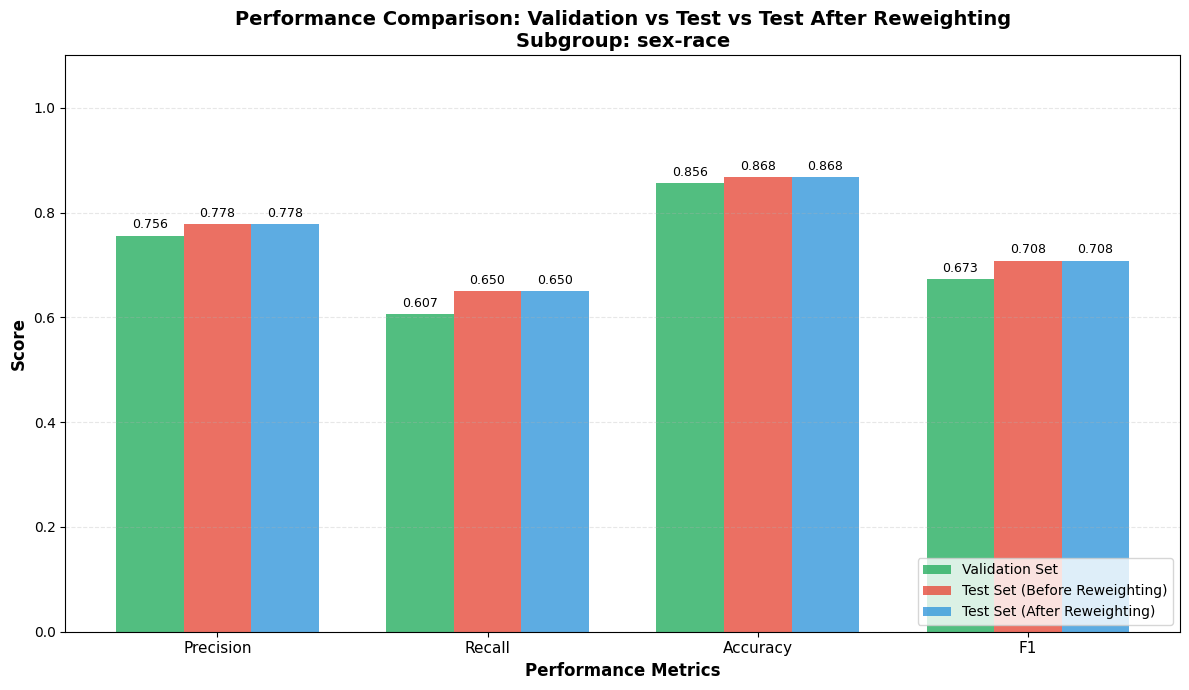


Performance Metrics Comparison:
Metric          Validation      Test (Before)   Test (After)    Δ (After-Before)
--------------------------------------------------------------------------------
Precision       0.7560          0.7778          0.7778          +0.0000
Recall          0.6067          0.6501          0.6501          +0.0000
Accuracy        0.8559          0.8678          0.8678          +0.0000
F1              0.6732          0.7082          0.7082          +0.0000


In [ ]:
# Plot performance comparison
plot_performance_comparison(performance_metrics_val, performance_metrics_test, performance_metrics_after, sensible_attribute)

---

# Penalty After Reweighting Plots

### Utils

In [ ]:
penalties_ontest_after_reweighting = {}
cm_dict_reweighted = {}

fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']
for metric in fair_metrics:
    # print("FAIRNESS METRIC:", metric)
    weights_notsized = compute_weights_notsized(fixed_lambda, metric, penalties_onval, X_train, sensible_attribute)
    penalties_ontest_after_reweighting[metric] = compute_penalties_after_reweighting(weights_notsized, metric, dataset_path, sensible_attribute, X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels) # Get only harmonic penalty
    # print("\n")

Training samples: 22792, Unique weights per group: {'00': 0.01, '01': 2.334418968212611, '10': 3.1706081081081074, '11': 0.7466061923210178}
{np.int64(0): array([[1408,   22],
       [  89,   91]]), np.int64(1): array([[2043,  206],
       [ 328,  698]])}
{np.int64(1): array([[2965,  220],
       [ 371,  759]]), np.int64(0): array([[486,   8],
       [ 46,  30]])}
{'01': array([[1145,   21],
       [  74,   83]]), '00': array([[261,   3],
       [ 13,  10]]), '11': array([[1825,  194],
       [ 304,  669]]), '10': array([[224,   6],
       [ 31,  22]])}
Training samples: 22792, Unique weights per group: {'00': 1.7323717948717945, '01': 2.809764991896272, '10': 2.4122742106860953, '11': 0.01}
{np.int64(0): array([[1406,   24],
       [  88,   92]]), np.int64(1): array([[2044,  205],
       [ 382,  644]])}
{np.int64(1): array([[2971,  214],
       [ 437,  693]]), np.int64(0): array([[479,  15],
       [ 33,  43]])}
{'01': array([[1146,   20],
       [  76,   81]]), '00': array([[262,   2

## Penalty before and after reweighting

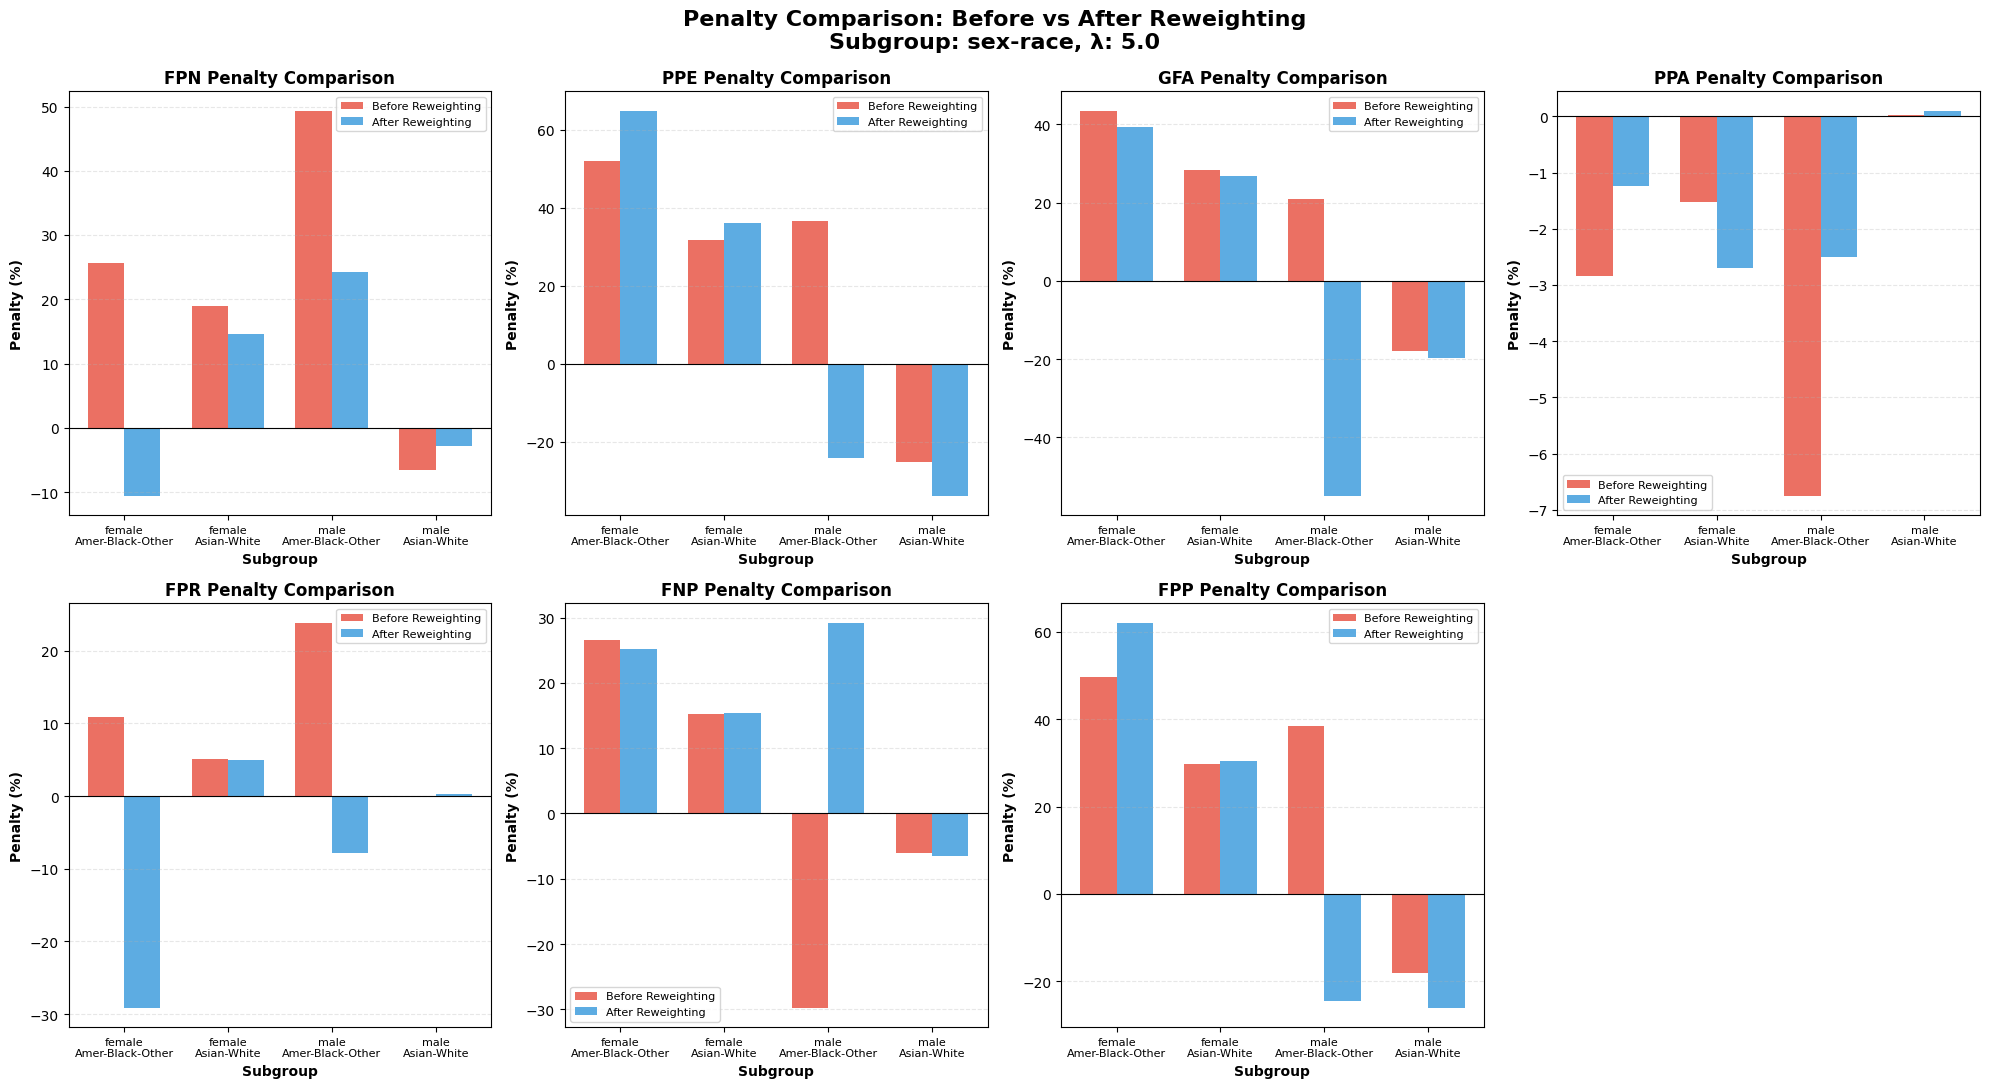

In [ ]:
# Use as many fairness metrics as needed
fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'FPR', 'FNP', 'FPP']
plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, 
                                        sensible_attribute, mapping, fixed_lambda)

Training samples: 22792, Unique weights per group: {'00': 0.01, '01': 2.334418968212611, '10': 3.1706081081081074, '11': 0.7466061923210178}
{np.int64(0): array([[1408,   22],
       [  89,   91]]), np.int64(1): array([[2043,  206],
       [ 328,  698]])}
{np.int64(1): array([[2965,  220],
       [ 371,  759]]), np.int64(0): array([[486,   8],
       [ 46,  30]])}
{'01': array([[1145,   21],
       [  74,   83]]), '00': array([[261,   3],
       [ 13,  10]]), '11': array([[1825,  194],
       [ 304,  669]]), '10': array([[224,   6],
       [ 31,  22]])}


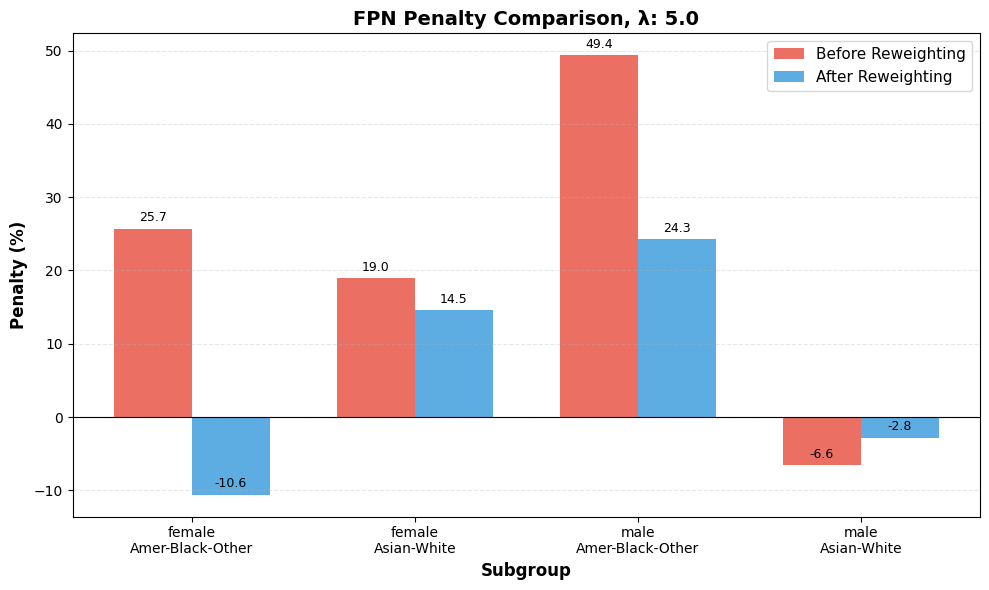


FPN - Penalty Changes:
  female-Amer-Black-Other: 25.71 → -10.58 (Δ = -36.29)
  female-Asian-White: 18.99 → 14.54 (Δ = -4.45)
  male-Amer-Black-Other: 49.35 → 24.25 (Δ = -25.10)
  male-Asian-White: -6.60 → -2.82 (Δ = +3.79)
------------------------------------------------------------


In [ ]:
metrics = ['FPN']
penalties_ontest_after_reweighting = {}
for metric in metrics:
    weights_notsized = compute_weights_notsized(fixed_lambda, metric, penalties_onval, X_train, sensible_attribute)
    penalties_ontest_after_reweighting[metric]= compute_penalties_after_reweighting(weights_notsized, metric, dataset_path, sensible_attribute, X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels) # Get only harmonic penalty

plot_penalty_comparison_all_individual(metrics, penalties_ontest, penalties_ontest_after_reweighting, sensible_attribute, mapping, fixed_lambda)

Training samples: 22792, Unique weights per group: {'00': 0.5854166666666667, '01': 1.1334418968212612, '10': 1.2170608108108107, '11': 0.9746606192321018}
{np.int64(0): array([[1408,   22],
       [  88,   92]]), np.int64(1): array([[2047,  202],
       [ 334,  692]])}
{np.int64(1): array([[2967,  218],
       [ 376,  754]]), np.int64(0): array([[488,   6],
       [ 46,  30]])}
{'01': array([[1136,   30],
       [  71,   86]]), '00': array([[262,   2],
       [ 14,   9]]), '11': array([[1812,  207],
       [ 286,  687]]), '10': array([[225,   5],
       [ 33,  20]])}


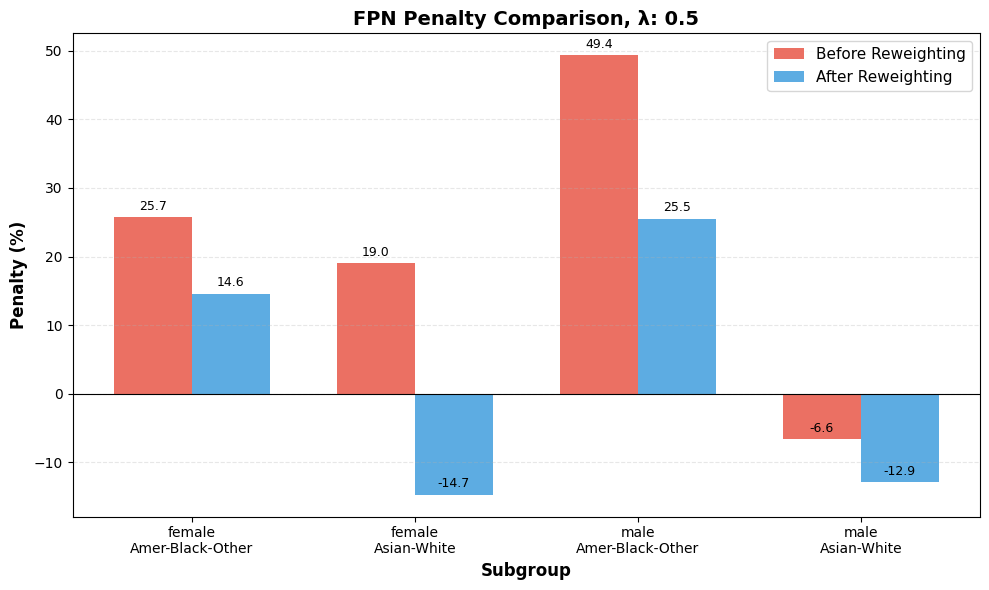


FPN - Penalty Changes:
  female-Amer-Black-Other: 25.71 → 14.58 (Δ = -11.13)
  female-Asian-White: 18.99 → -14.72 (Δ = -33.72)
  male-Amer-Black-Other: 49.35 → 25.53 (Δ = -23.83)
  male-Asian-White: -6.60 → -12.91 (Δ = -6.31)
------------------------------------------------------------
Training samples: 22792, Unique weights per group: {'00': 0.17083333333333328, '01': 1.2668837936425221, '10': 1.4341216216216215, '11': 0.9493212384642036}
{np.int64(0): array([[1408,   22],
       [  91,   89]]), np.int64(1): array([[2045,  204],
       [ 332,  694]])}
{np.int64(1): array([[2965,  220],
       [ 376,  754]]), np.int64(0): array([[488,   6],
       [ 47,  29]])}
{'01': array([[1146,   20],
       [  76,   81]]), '00': array([[261,   3],
       [ 14,   9]]), '11': array([[1819,  200],
       [ 301,  672]]), '10': array([[225,   5],
       [ 33,  20]])}


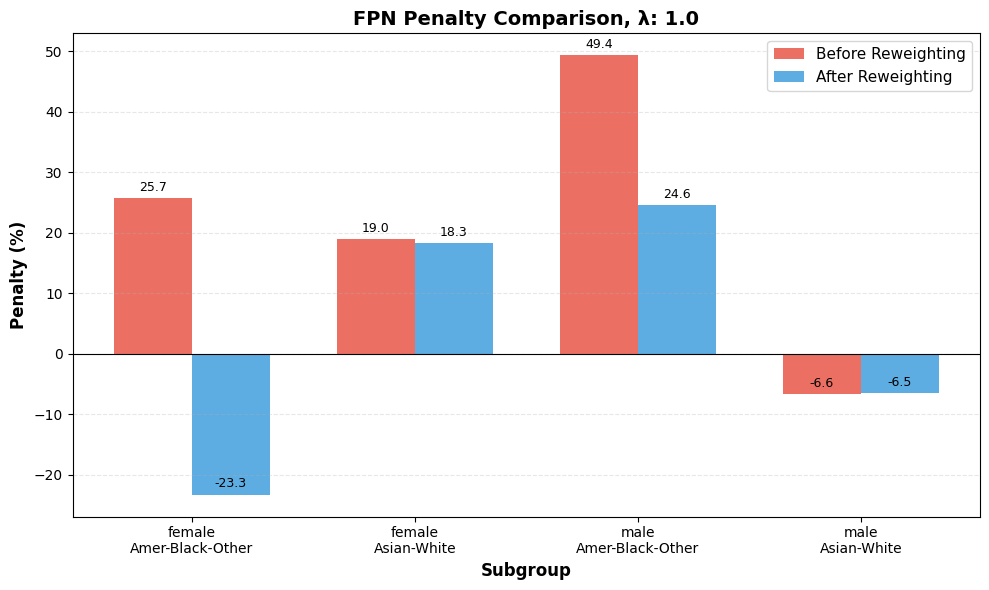


FPN - Penalty Changes:
  female-Amer-Black-Other: 25.71 → -23.26 (Δ = -48.97)
  female-Asian-White: 18.99 → 18.28 (Δ = -0.71)
  male-Amer-Black-Other: 49.35 → 24.60 (Δ = -24.75)
  male-Asian-White: -6.60 → -6.52 (Δ = +0.09)
------------------------------------------------------------
Training samples: 22792, Unique weights per group: {'00': 0.01, '01': 1.5337675872850443, '10': 1.868243243243243, '11': 0.8986424769284072}
{np.int64(0): array([[1408,   22],
       [  89,   91]]), np.int64(1): array([[2044,  205],
       [ 331,  695]])}
{np.int64(1): array([[2967,  218],
       [ 375,  755]]), np.int64(0): array([[485,   9],
       [ 45,  31]])}
{'01': array([[1146,   20],
       [  76,   81]]), '00': array([[261,   3],
       [ 14,   9]]), '11': array([[1823,  196],
       [ 299,  674]]), '10': array([[226,   4],
       [ 32,  21]])}


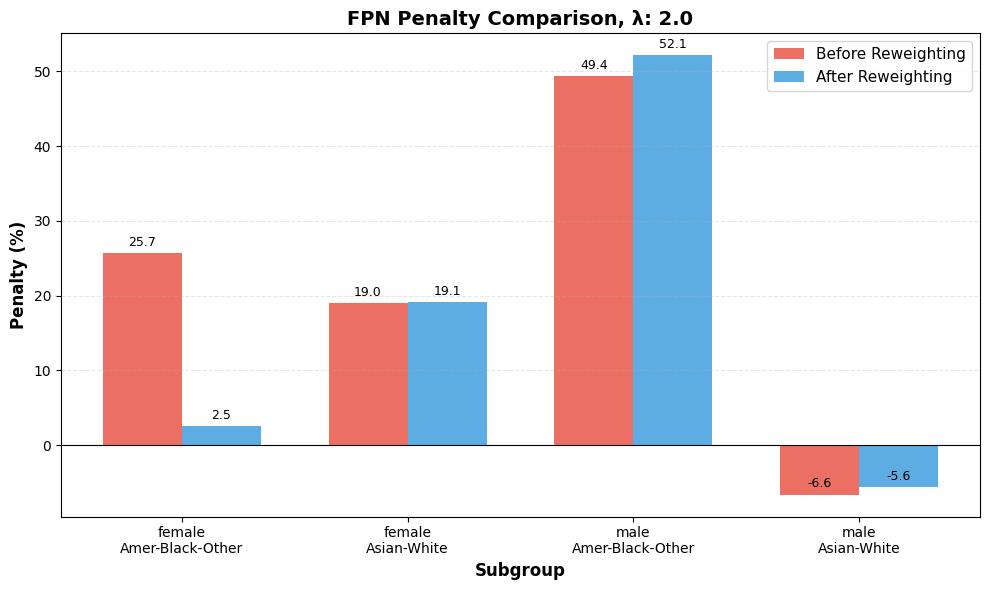


FPN - Penalty Changes:
  female-Amer-Black-Other: 25.71 → 2.54 (Δ = -23.17)
  female-Asian-White: 18.99 → 19.11 (Δ = +0.12)
  male-Amer-Black-Other: 49.35 → 52.14 (Δ = +2.79)
  male-Asian-White: -6.60 → -5.62 (Δ = +0.99)
------------------------------------------------------------
Training samples: 22792, Unique weights per group: {'00': 0.01, '01': 2.334418968212611, '10': 3.1706081081081074, '11': 0.7466061923210178}
{np.int64(0): array([[1408,   22],
       [  89,   91]]), np.int64(1): array([[2043,  206],
       [ 328,  698]])}
{np.int64(1): array([[2965,  220],
       [ 371,  759]]), np.int64(0): array([[486,   8],
       [ 46,  30]])}
{'01': array([[1145,   21],
       [  74,   83]]), '00': array([[261,   3],
       [ 13,  10]]), '11': array([[1825,  194],
       [ 304,  669]]), '10': array([[224,   6],
       [ 31,  22]])}


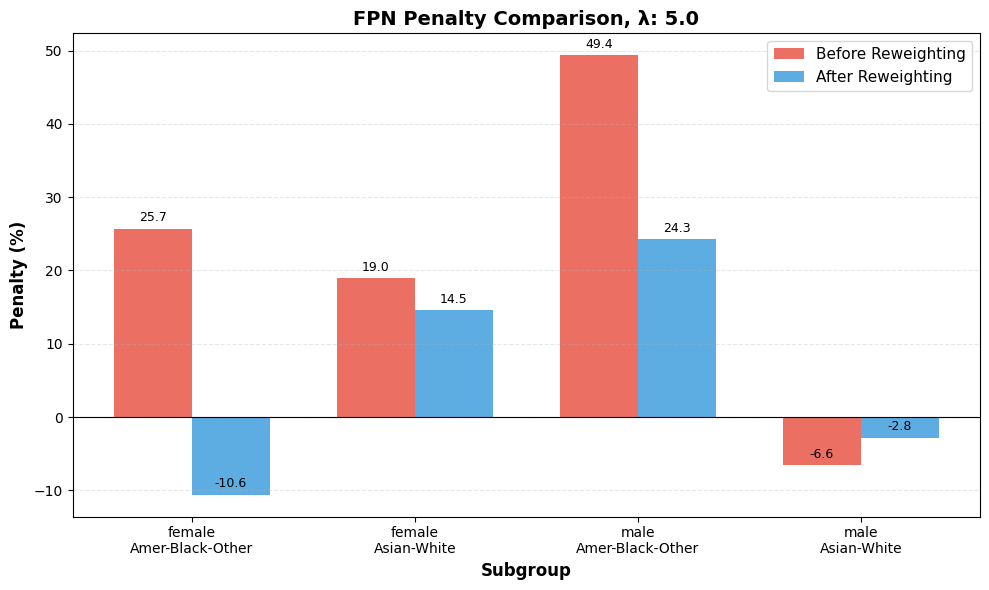


FPN - Penalty Changes:
  female-Amer-Black-Other: 25.71 → -10.58 (Δ = -36.29)
  female-Asian-White: 18.99 → 14.54 (Δ = -4.45)
  male-Amer-Black-Other: 49.35 → 24.25 (Δ = -25.10)
  male-Asian-White: -6.60 → -2.82 (Δ = +3.79)
------------------------------------------------------------
Training samples: 22792, Unique weights per group: {'00': 0.01, '01': 3.6688379364252213, '10': 5.341216216216215, '11': 0.49321238464203554}
{np.int64(0): array([[1406,   24],
       [  87,   93]]), np.int64(1): array([[2050,  199],
       [ 343,  683]])}
{np.int64(1): array([[2974,  211],
       [ 386,  744]]), np.int64(0): array([[482,  12],
       [ 44,  32]])}
{'01': array([[1146,   20],
       [  75,   82]]), '00': array([[261,   3],
       [ 13,  10]]), '11': array([[1818,  201],
       [ 293,  680]]), '10': array([[224,   6],
       [ 31,  22]])}


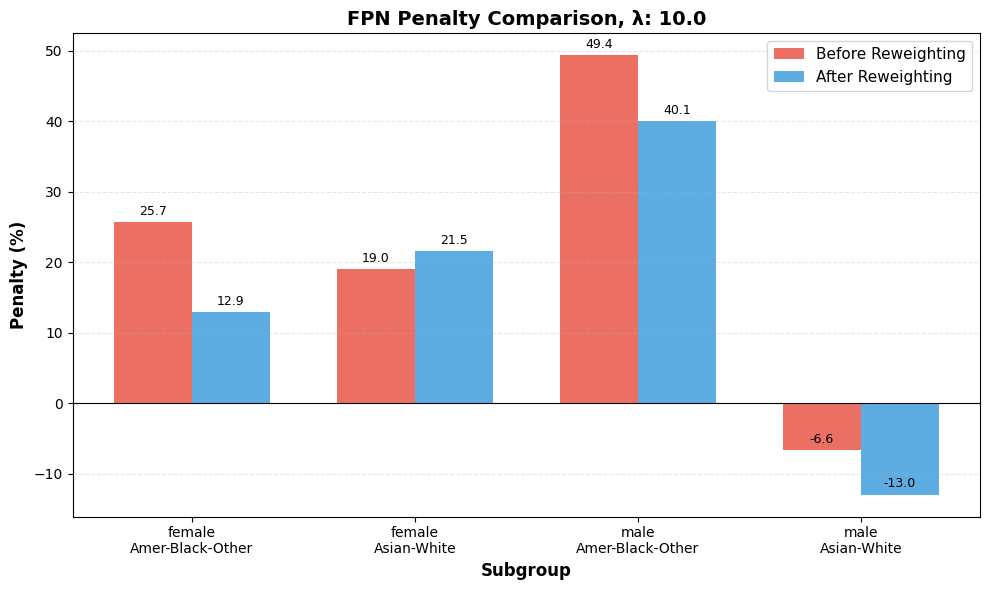


FPN - Penalty Changes:
  female-Amer-Black-Other: 25.71 → 12.89 (Δ = -12.82)
  female-Asian-White: 18.99 → 21.53 (Δ = +2.54)
  male-Amer-Black-Other: 49.35 → 40.08 (Δ = -9.28)
  male-Asian-White: -6.60 → -12.97 (Δ = -6.37)
------------------------------------------------------------


In [ ]:
for l in lambdas:
    penalties_ontest_after_reweighting = {}

    weights_notsized = compute_weights_notsized(l, 'FPN', penalties_onval, X_train, sensible_attribute)
    penalties_ontest_after_reweighting['FPN']= compute_penalties_after_reweighting(weights_notsized, 'FPN', dataset_path, sensible_attribute, X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels) # Get only harmonic penalty

    plot_penalty_comparison_all_individual(['FPN'], penalties_ontest, penalties_ontest_after_reweighting, 
                                            sensible_attribute, mapping, l)

In [ ]:
if ALL_FM_L_NOTSIZED == 1:
    for l in lambdas:
        penalties_ontest_after_reweighting = {}

        for metric in fair_metrics:
            # print("FAIRNESS METRIC:", metric)
            weights_notsized = compute_weights_notsized(l, metric, penalties_onval, X_train, sensible_attribute)
            penalties_ontest_after_reweighting[metric]= compute_penalties_after_reweighting(weights_notsized, metric, dataset_path, sensible_attribute, X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels) # Get only harmonic penalty
            # print("\n")

        plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, 
                                                    sensible_attribute, mapping, l)

Training samples: 22792, Unique weights per group: {'00': 0.9628189721146028, '01': 1.0599521565428853, '10': 1.0208993835635032, '11': 0.9746606192321018}
{np.int64(0): array([[1407,   23],
       [  88,   92]]), np.int64(1): array([[2046,  203],
       [ 331,  695]])}
{np.int64(1): array([[2967,  218],
       [ 373,  757]]), np.int64(0): array([[486,   8],
       [ 46,  30]])}
{'01': array([[1146,   20],
       [  77,   80]]), '00': array([[262,   2],
       [ 14,   9]]), '11': array([[1824,  195],
       [ 304,  669]]), '10': array([[225,   5],
       [ 32,  21]])}
Training samples: 22792, Unique weights per group: {'00': 1.0065681212770106, '01': 1.0813082822446152, '10': 1.0135978762429383, '11': 0.8591206279623073}
{np.int64(0): array([[1408,   22],
       [  91,   89]]), np.int64(1): array([[2044,  205],
       [ 330,  696]])}
{np.int64(1): array([[2964,  221],
       [ 374,  756]]), np.int64(0): array([[488,   6],
       [ 47,  29]])}
{'01': array([[1146,   20],
       [  77,  

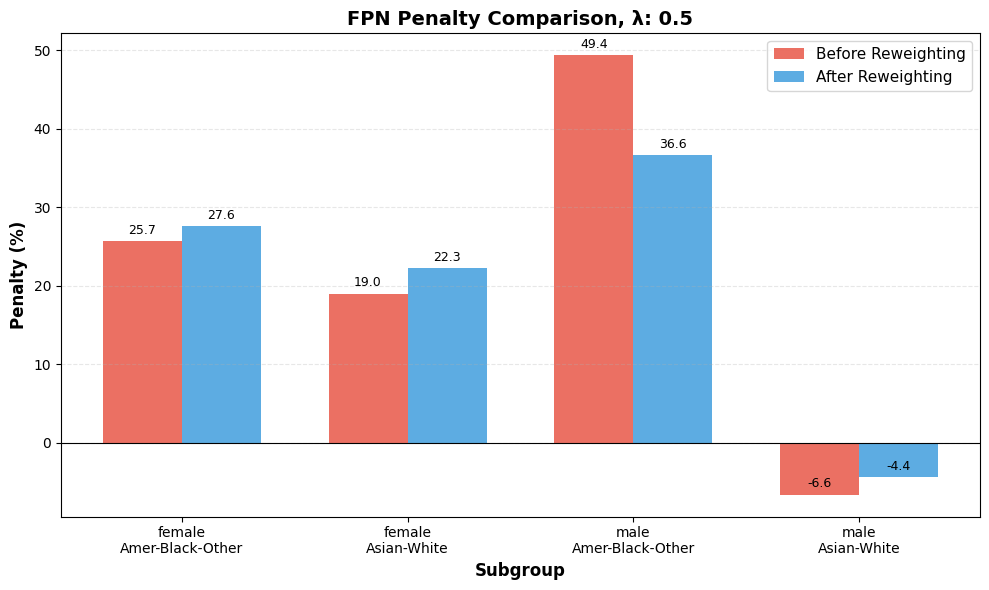


FPN - Penalty Changes:
  female-Amer-Black-Other: 25.71 → 27.65 (Δ = +1.94)
  female-Asian-White: 18.99 → 22.30 (Δ = +3.31)
  male-Amer-Black-Other: 49.35 → 36.62 (Δ = -12.74)
  male-Asian-White: -6.60 → -4.37 (Δ = +2.24)
------------------------------------------------------------


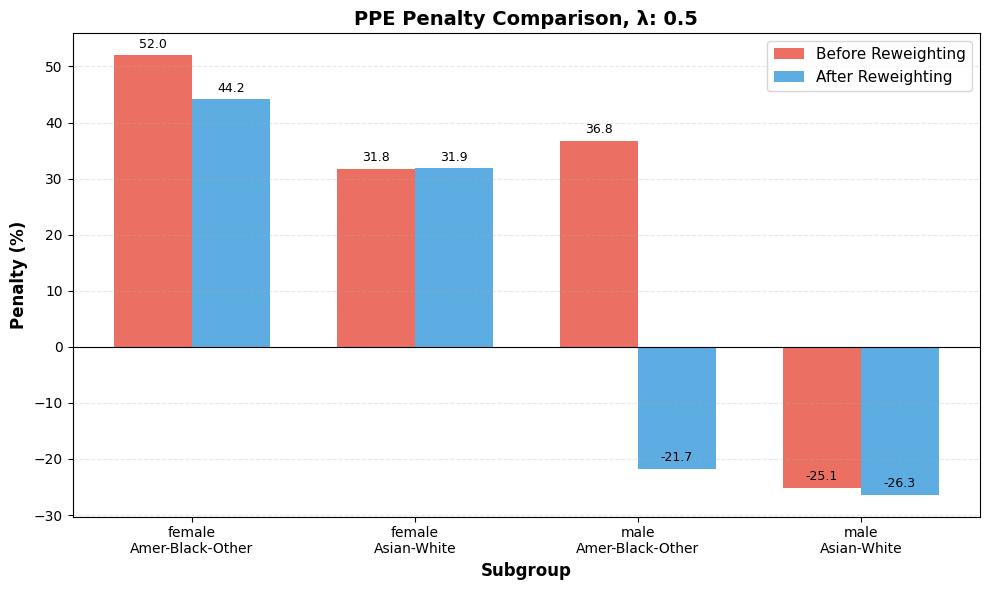


PPE - Penalty Changes:
  female-Amer-Black-Other: 51.99 → 44.19 (Δ = -7.80)
  female-Asian-White: 31.78 → 31.89 (Δ = +0.11)
  male-Amer-Black-Other: 36.76 → -21.70 (Δ = -58.47)
  male-Asian-White: -25.11 → -26.35 (Δ = -1.24)
------------------------------------------------------------


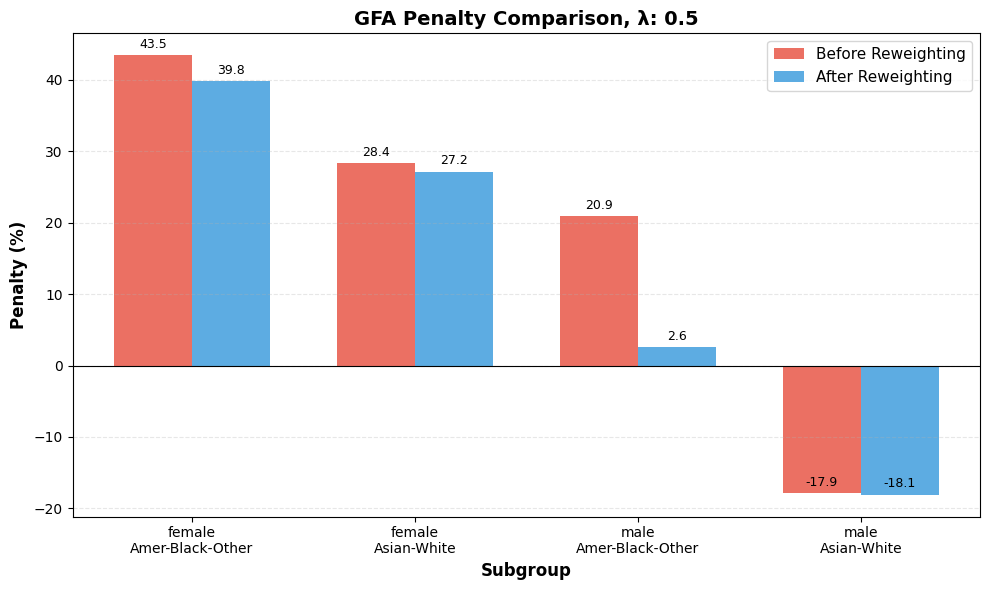


GFA - Penalty Changes:
  female-Amer-Black-Other: 43.46 → 39.82 (Δ = -3.63)
  female-Asian-White: 28.41 → 27.17 (Δ = -1.24)
  male-Amer-Black-Other: 20.95 → 2.57 (Δ = -18.38)
  male-Asian-White: -17.91 → -18.08 (Δ = -0.17)
------------------------------------------------------------


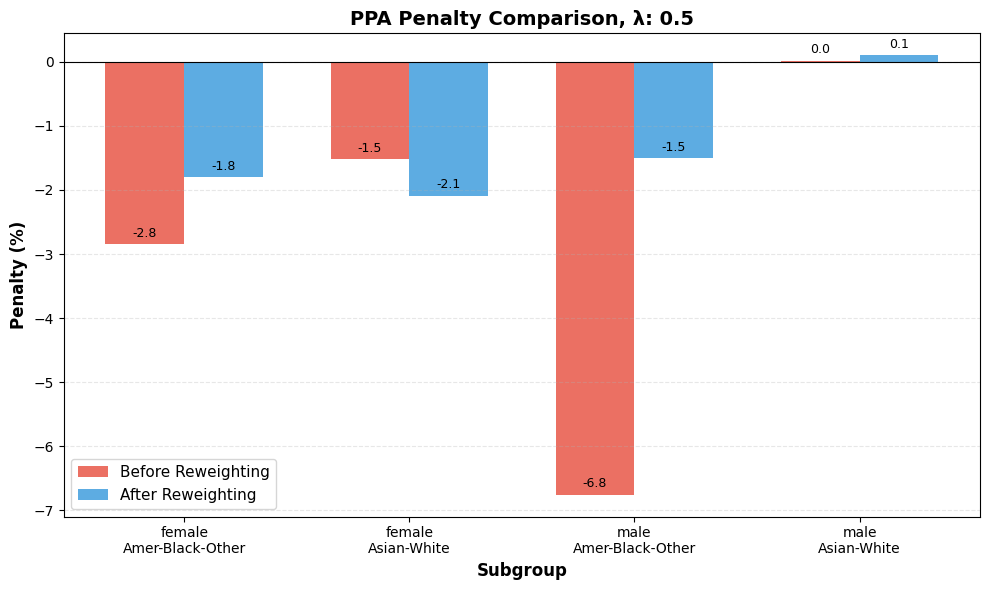


PPA - Penalty Changes:
  female-Amer-Black-Other: -2.84 → -1.81 (Δ = +1.03)
  female-Asian-White: -1.52 → -2.09 (Δ = -0.57)
  male-Amer-Black-Other: -6.75 → -1.50 (Δ = +5.25)
  male-Asian-White: 0.02 → 0.10 (Δ = +0.08)
------------------------------------------------------------


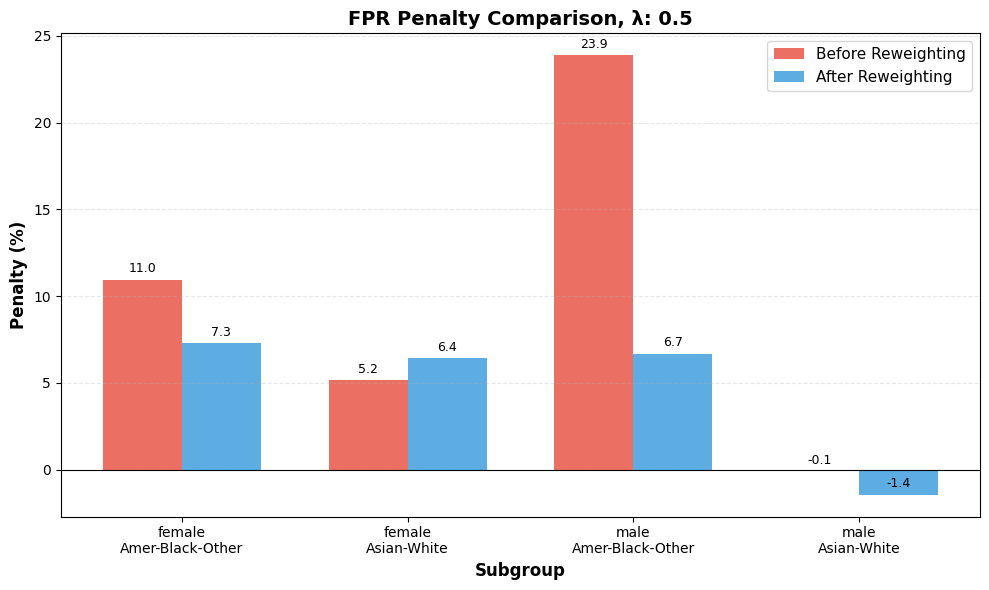


FPR - Penalty Changes:
  female-Amer-Black-Other: 10.95 → 7.28 (Δ = -3.67)
  female-Asian-White: 5.16 → 6.44 (Δ = +1.28)
  male-Amer-Black-Other: 23.87 → 6.69 (Δ = -17.18)
  male-Asian-White: -0.06 → -1.43 (Δ = -1.37)
------------------------------------------------------------


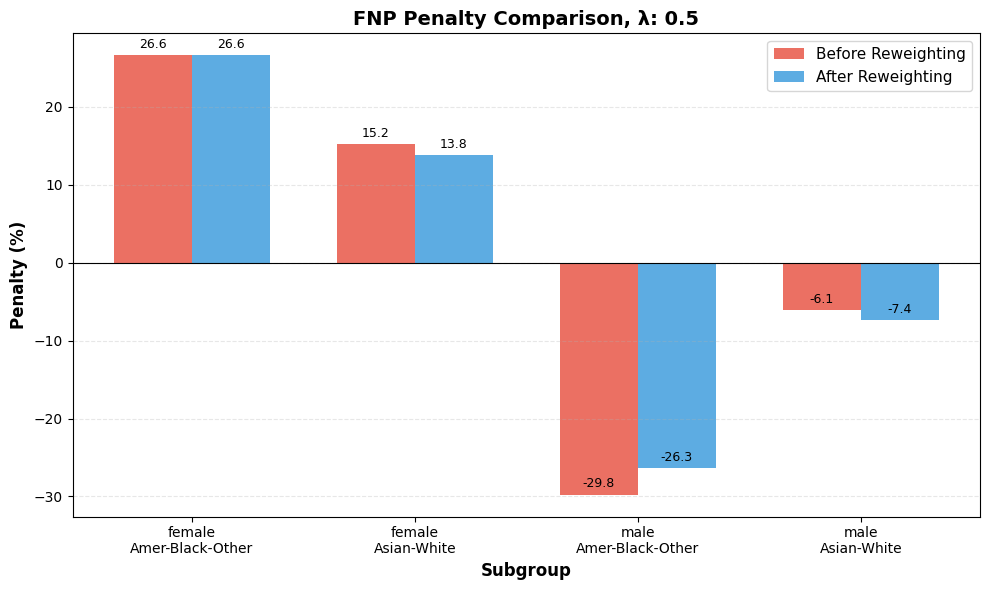


FNP - Penalty Changes:
  female-Amer-Black-Other: 26.63 → 26.63 (Δ = +0.00)
  female-Asian-White: 15.21 → 13.84 (Δ = -1.37)
  male-Amer-Black-Other: -29.76 → -26.34 (Δ = +3.42)
  male-Asian-White: -6.12 → -7.39 (Δ = -1.26)
------------------------------------------------------------


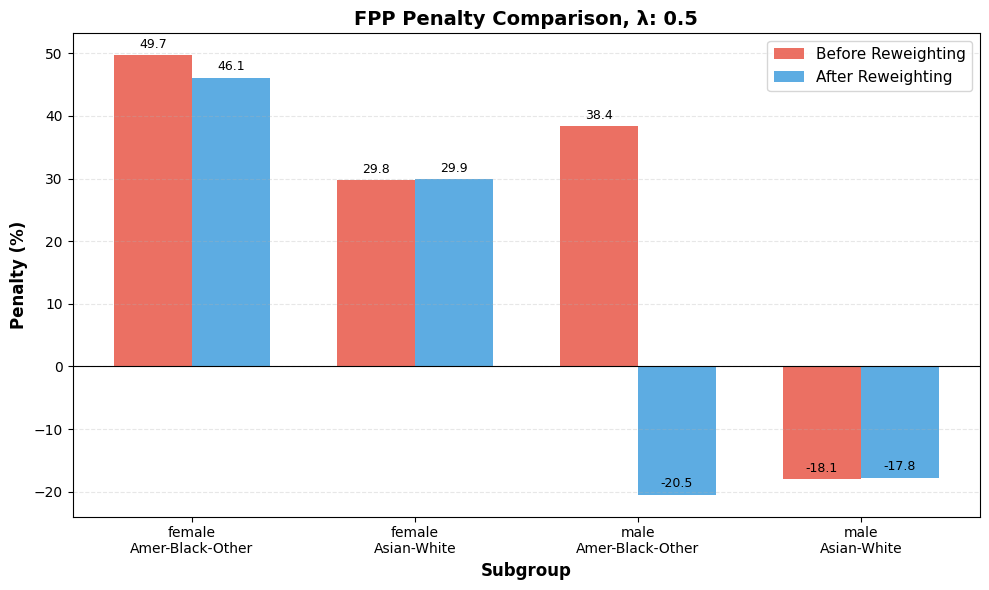


FPP - Penalty Changes:
  female-Amer-Black-Other: 49.68 → 46.13 (Δ = -3.55)
  female-Asian-White: 29.79 → 29.86 (Δ = +0.07)
  male-Amer-Black-Other: 38.36 → -20.46 (Δ = -58.82)
  male-Asian-White: -18.05 → -17.76 (Δ = +0.30)
------------------------------------------------------------
Training samples: 22792, Unique weights per group: {'00': 0.9256379442292055, '01': 1.1199043130857709, '10': 1.0417987671270064, '11': 0.9493212384642036}
{np.int64(0): array([[1408,   22],
       [  92,   88]]), np.int64(1): array([[2048,  201],
       [ 336,  690]])}
{np.int64(1): array([[2969,  216],
       [ 382,  748]]), np.int64(0): array([[487,   7],
       [ 46,  30]])}
{'01': array([[1135,   31],
       [  70,   87]]), '00': array([[262,   2],
       [ 14,   9]]), '11': array([[1806,  213],
       [ 281,  692]]), '10': array([[224,   6],
       [ 33,  20]])}
Training samples: 22792, Unique weights per group: {'00': 1.0131362425540213, '01': 1.1626165644892303, '10': 1.0271957524858766, '11': 0.

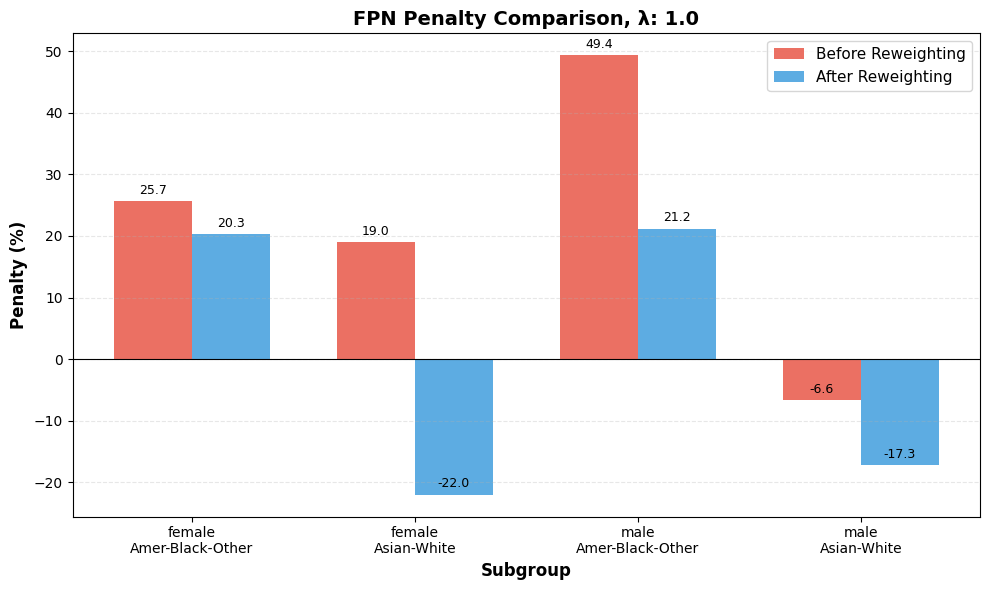


FPN - Penalty Changes:
  female-Amer-Black-Other: 25.71 → 20.29 (Δ = -5.42)
  female-Asian-White: 18.99 → -22.01 (Δ = -41.00)
  male-Amer-Black-Other: 49.35 → 21.21 (Δ = -28.15)
  male-Asian-White: -6.60 → -17.28 (Δ = -10.68)
------------------------------------------------------------


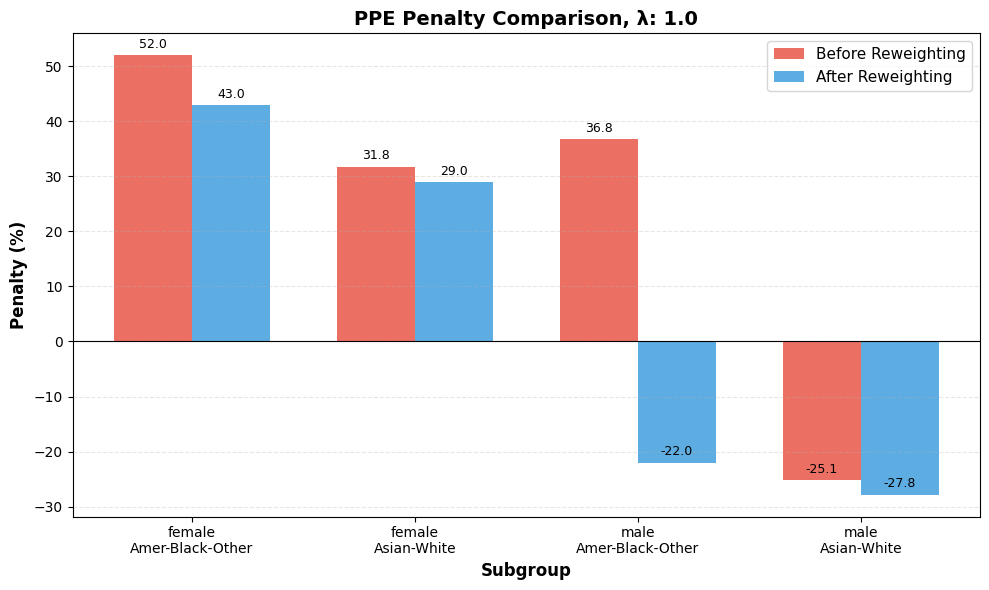


PPE - Penalty Changes:
  female-Amer-Black-Other: 51.99 → 43.02 (Δ = -8.97)
  female-Asian-White: 31.78 → 28.95 (Δ = -2.83)
  male-Amer-Black-Other: 36.76 → -21.99 (Δ = -58.75)
  male-Asian-White: -25.11 → -27.81 (Δ = -2.70)
------------------------------------------------------------


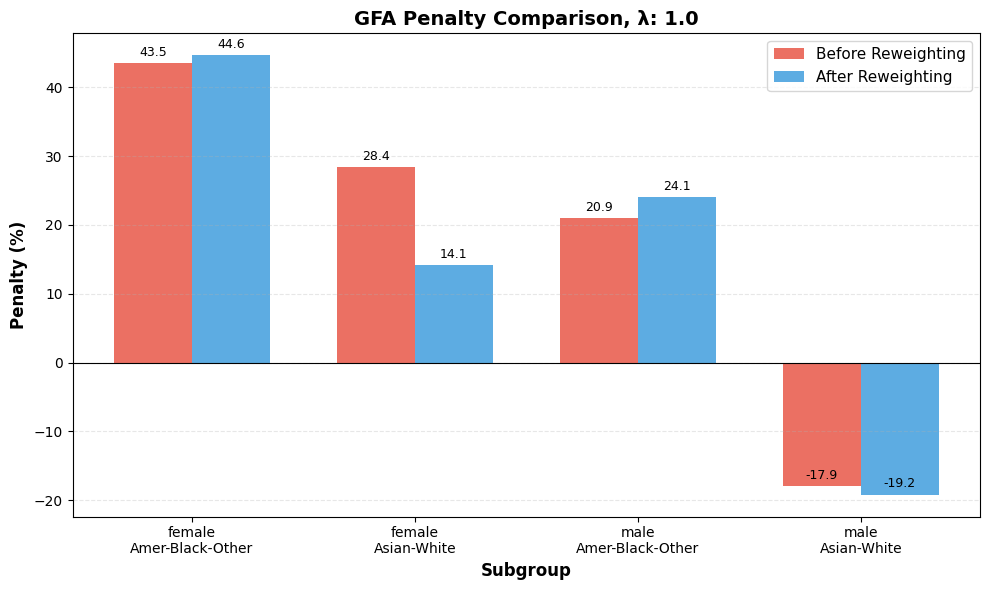


GFA - Penalty Changes:
  female-Amer-Black-Other: 43.46 → 44.64 (Δ = +1.18)
  female-Asian-White: 28.41 → 14.11 (Δ = -14.30)
  male-Amer-Black-Other: 20.95 → 24.09 (Δ = +3.15)
  male-Asian-White: -17.91 → -19.18 (Δ = -1.27)
------------------------------------------------------------


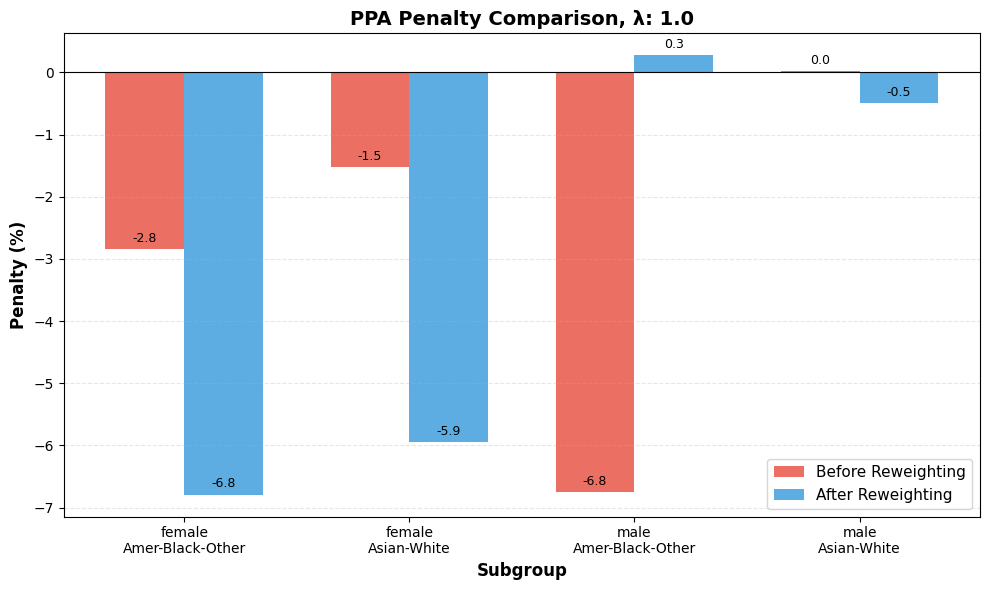


PPA - Penalty Changes:
  female-Amer-Black-Other: -2.84 → -6.79 (Δ = -3.95)
  female-Asian-White: -1.52 → -5.94 (Δ = -4.42)
  male-Amer-Black-Other: -6.75 → 0.28 (Δ = +7.03)
  male-Asian-White: 0.02 → -0.49 (Δ = -0.51)
------------------------------------------------------------


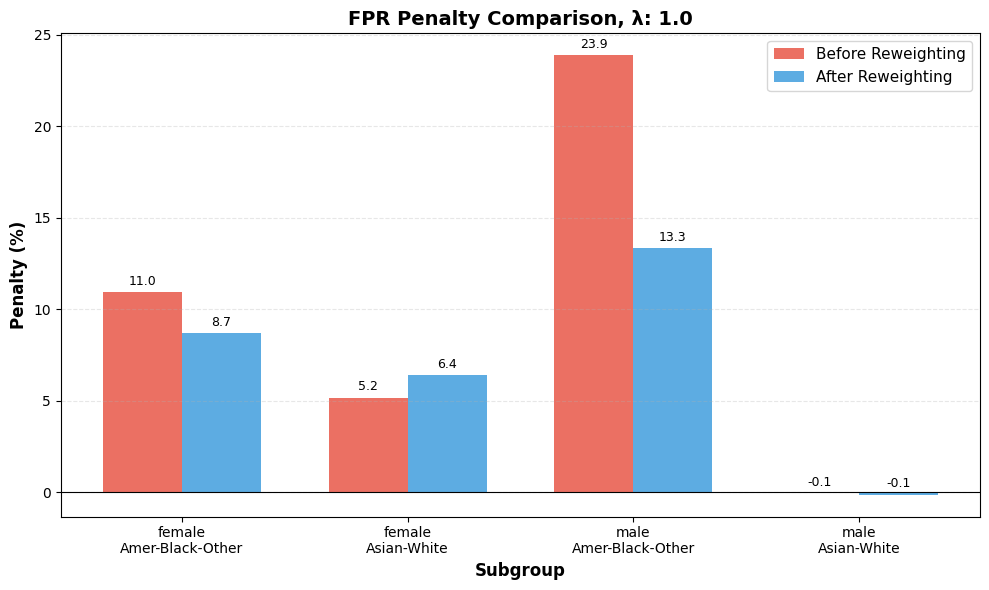


FPR - Penalty Changes:
  female-Amer-Black-Other: 10.95 → 8.68 (Δ = -2.27)
  female-Asian-White: 5.16 → 6.38 (Δ = +1.22)
  male-Amer-Black-Other: 23.87 → 13.31 (Δ = -10.56)
  male-Asian-White: -0.06 → -0.14 (Δ = -0.08)
------------------------------------------------------------


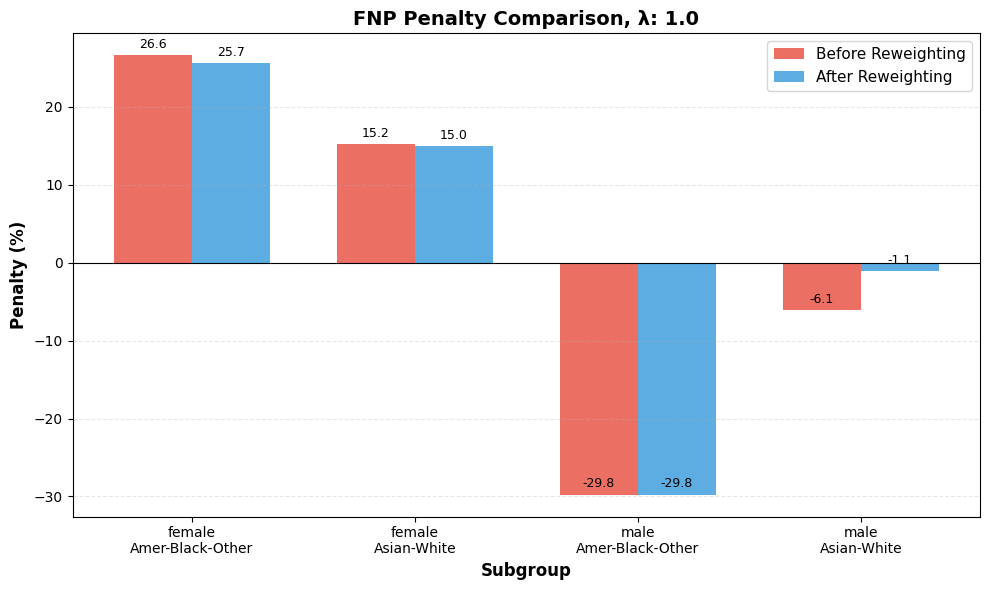


FNP - Penalty Changes:
  female-Amer-Black-Other: 26.63 → 25.66 (Δ = -0.97)
  female-Asian-White: 15.21 → 14.99 (Δ = -0.22)
  male-Amer-Black-Other: -29.76 → -29.76 (Δ = +0.00)
  male-Asian-White: -6.12 → -1.07 (Δ = +5.05)
------------------------------------------------------------


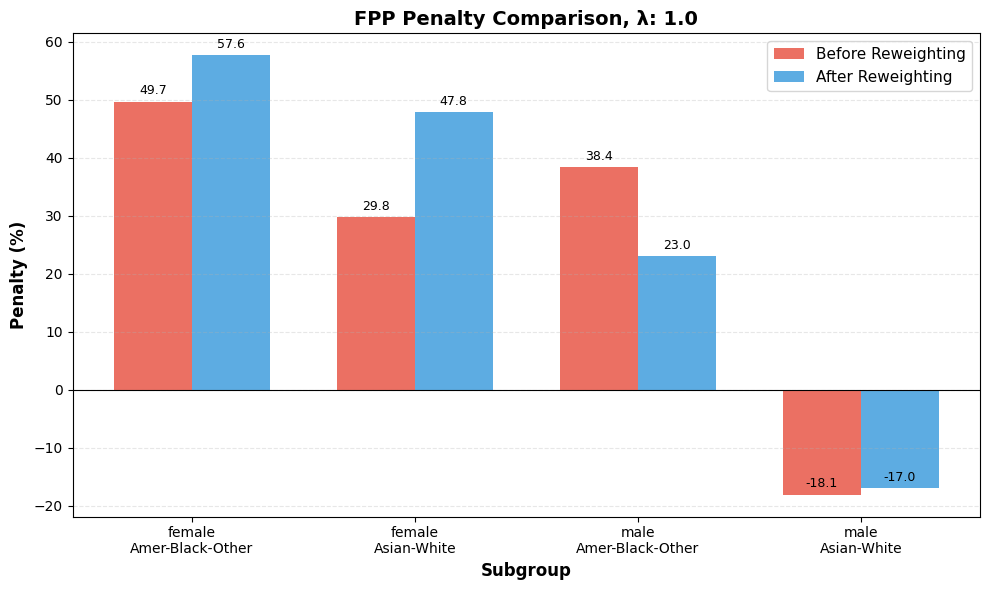


FPP - Penalty Changes:
  female-Amer-Black-Other: 49.68 → 57.64 (Δ = +7.97)
  female-Asian-White: 29.79 → 47.79 (Δ = +18.00)
  male-Amer-Black-Other: 38.36 → 23.01 (Δ = -15.34)
  male-Asian-White: -18.05 → -17.00 (Δ = +1.06)
------------------------------------------------------------
Training samples: 22792, Unique weights per group: {'00': 0.8512758884584111, '01': 1.2398086261715415, '10': 1.083597534254013, '11': 0.8986424769284072}
{np.int64(0): array([[1408,   22],
       [  91,   89]]), np.int64(1): array([[2027,  222],
       [ 328,  698]])}
{np.int64(1): array([[2948,  237],
       [ 372,  758]]), np.int64(0): array([[487,   7],
       [ 47,  29]])}
{'01': array([[1146,   20],
       [  76,   81]]), '00': array([[262,   2],
       [ 14,   9]]), '11': array([[1821,  198],
       [ 296,  677]]), '10': array([[225,   5],
       [ 31,  22]])}
Training samples: 22792, Unique weights per group: {'00': 1.0262724851080425, '01': 1.3252331289784605, '10': 1.0543915049717532, '11': 0.4

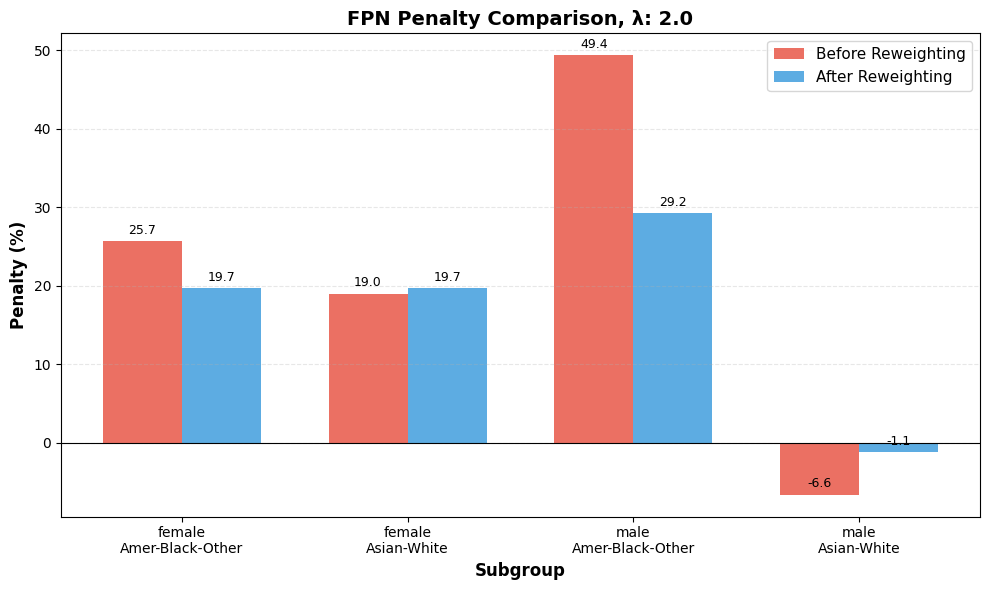


FPN - Penalty Changes:
  female-Amer-Black-Other: 25.71 → 19.68 (Δ = -6.03)
  female-Asian-White: 18.99 → 19.73 (Δ = +0.74)
  male-Amer-Black-Other: 49.35 → 29.22 (Δ = -20.13)
  male-Asian-White: -6.60 → -1.15 (Δ = +5.46)
------------------------------------------------------------


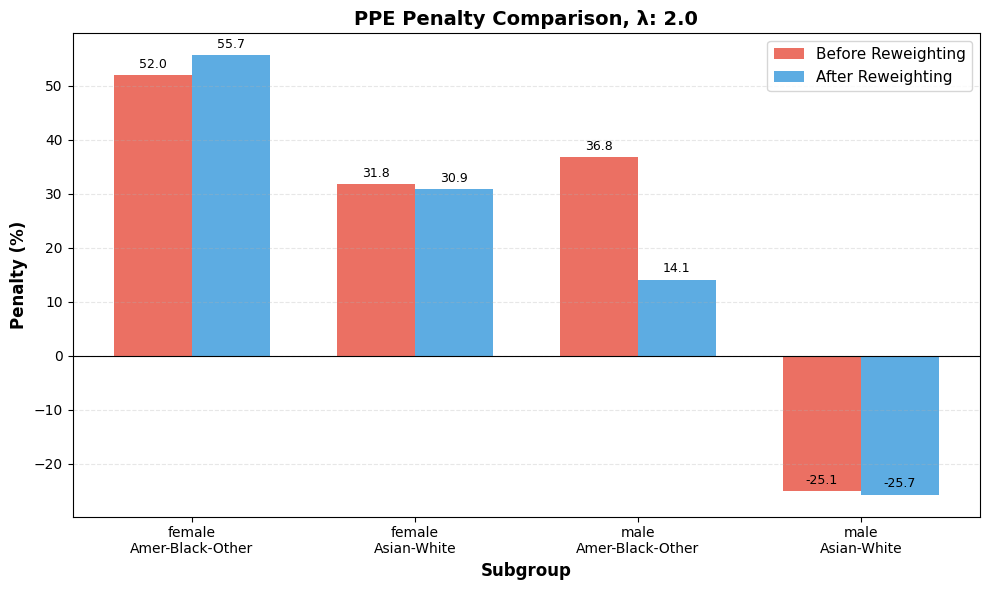


PPE - Penalty Changes:
  female-Amer-Black-Other: 51.99 → 55.66 (Δ = +3.67)
  female-Asian-White: 31.78 → 30.91 (Δ = -0.87)
  male-Amer-Black-Other: 36.76 → 14.10 (Δ = -22.67)
  male-Asian-White: -25.11 → -25.74 (Δ = -0.63)
------------------------------------------------------------


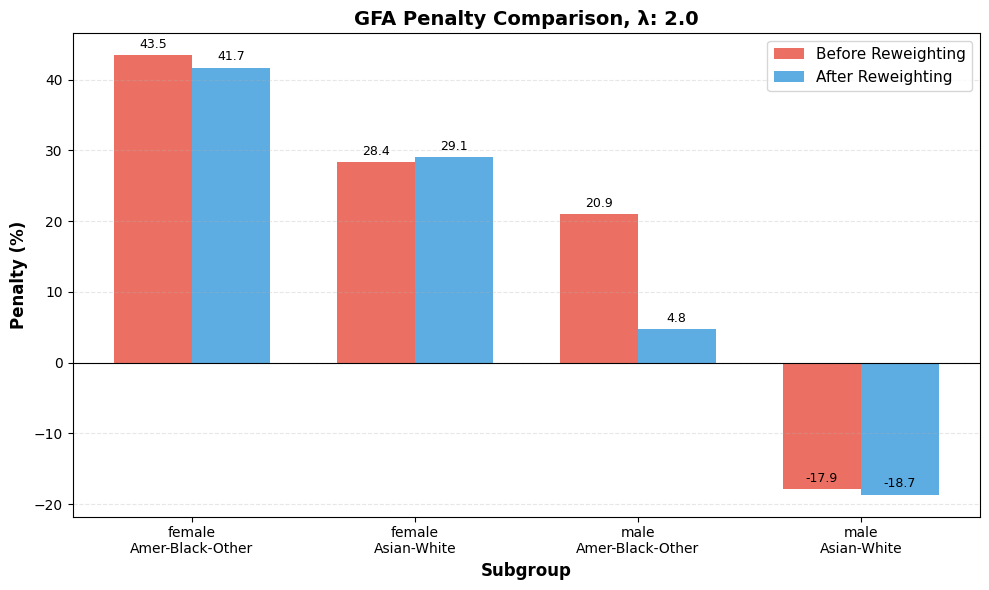


GFA - Penalty Changes:
  female-Amer-Black-Other: 43.46 → 41.73 (Δ = -1.73)
  female-Asian-White: 28.41 → 29.11 (Δ = +0.71)
  male-Amer-Black-Other: 20.95 → 4.78 (Δ = -16.17)
  male-Asian-White: -17.91 → -18.66 (Δ = -0.75)
------------------------------------------------------------


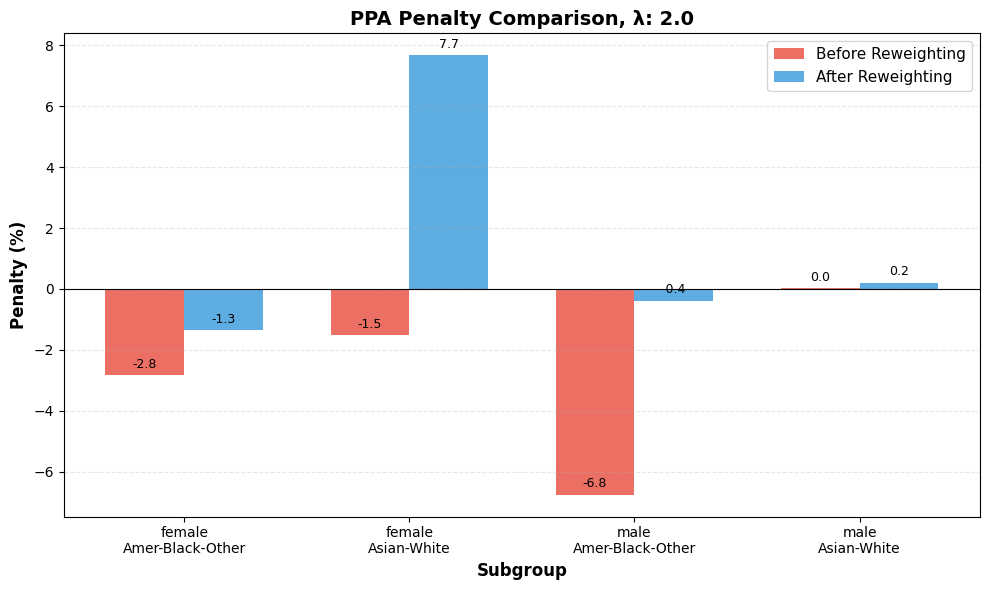


PPA - Penalty Changes:
  female-Amer-Black-Other: -2.84 → -1.35 (Δ = +1.49)
  female-Asian-White: -1.52 → 7.68 (Δ = +9.20)
  male-Amer-Black-Other: -6.75 → -0.38 (Δ = +6.37)
  male-Asian-White: 0.02 → 0.21 (Δ = +0.19)
------------------------------------------------------------


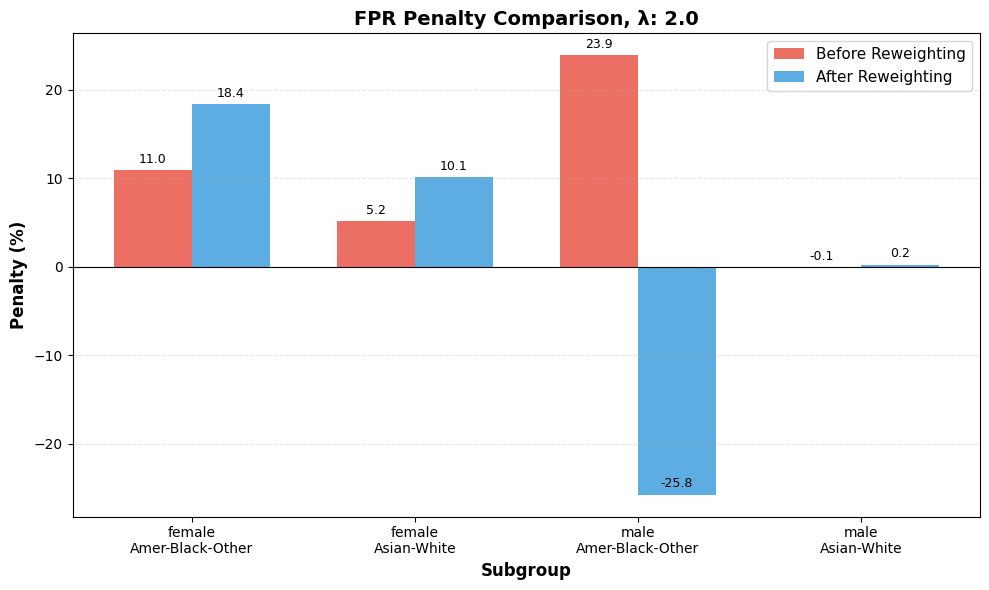


FPR - Penalty Changes:
  female-Amer-Black-Other: 10.95 → 18.37 (Δ = +7.42)
  female-Asian-White: 5.16 → 10.07 (Δ = +4.91)
  male-Amer-Black-Other: 23.87 → -25.75 (Δ = -49.63)
  male-Asian-White: -0.06 → 0.23 (Δ = +0.29)
------------------------------------------------------------


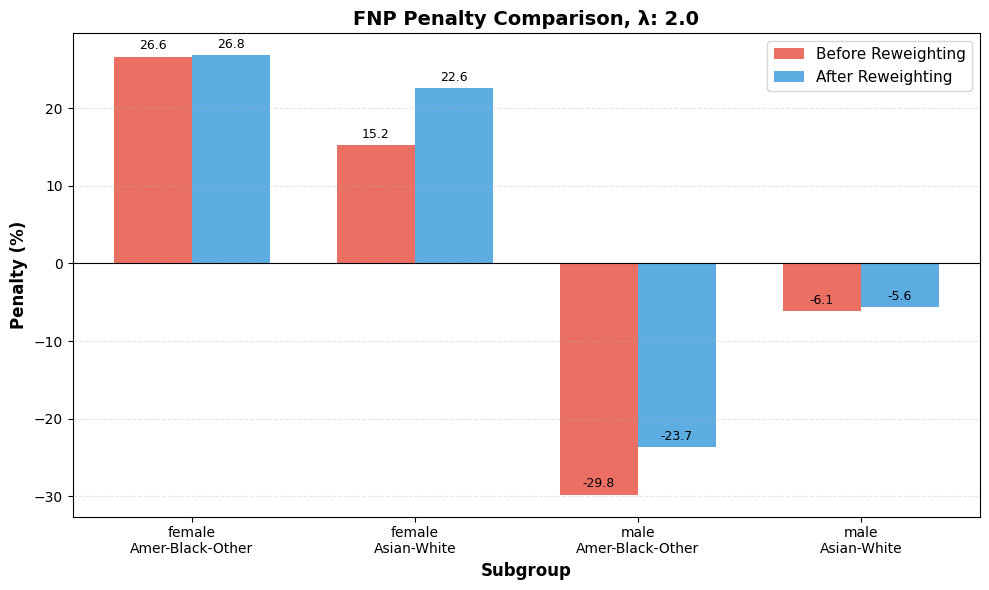


FNP - Penalty Changes:
  female-Amer-Black-Other: 26.63 → 26.79 (Δ = +0.16)
  female-Asian-White: 15.21 → 22.56 (Δ = +7.35)
  male-Amer-Black-Other: -29.76 → -23.67 (Δ = +6.09)
  male-Asian-White: -6.12 → -5.59 (Δ = +0.53)
------------------------------------------------------------


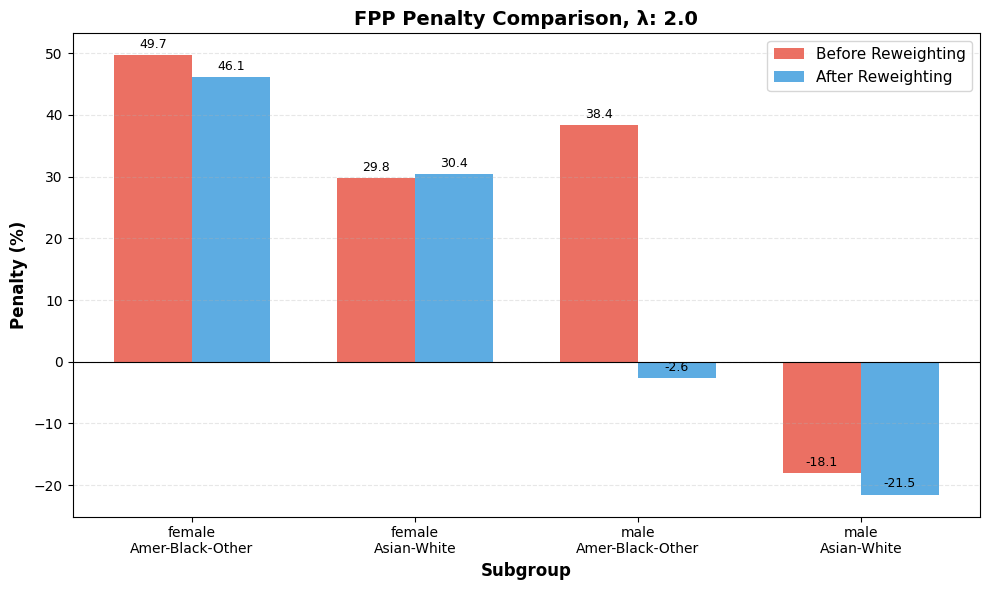


FPP - Penalty Changes:
  female-Amer-Black-Other: 49.68 → 46.13 (Δ = -3.55)
  female-Asian-White: 29.79 → 30.38 (Δ = +0.59)
  male-Amer-Black-Other: 38.36 → -2.62 (Δ = -40.98)
  male-Asian-White: -18.05 → -21.52 (Δ = -3.47)
------------------------------------------------------------
Training samples: 22792, Unique weights per group: {'00': 0.6281897211460276, '01': 1.5995215654288542, '10': 1.2089938356350323, '11': 0.7466061923210178}
{np.int64(0): array([[1408,   22],
       [  90,   90]]), np.int64(1): array([[2043,  206],
       [ 334,  692]])}
{np.int64(1): array([[2964,  221],
       [ 377,  753]]), np.int64(0): array([[487,   7],
       [ 47,  29]])}
{'01': array([[1146,   20],
       [  76,   81]]), '00': array([[262,   2],
       [ 14,   9]]), '11': array([[1810,  209],
       [ 284,  689]]), '10': array([[218,  12],
       [ 19,  34]])}
Training samples: 22792, Unique weights per group: {'00': 1.0656812127701065, '01': 1.8130828224461513, '10': 1.135978762429383, '11': 0.01

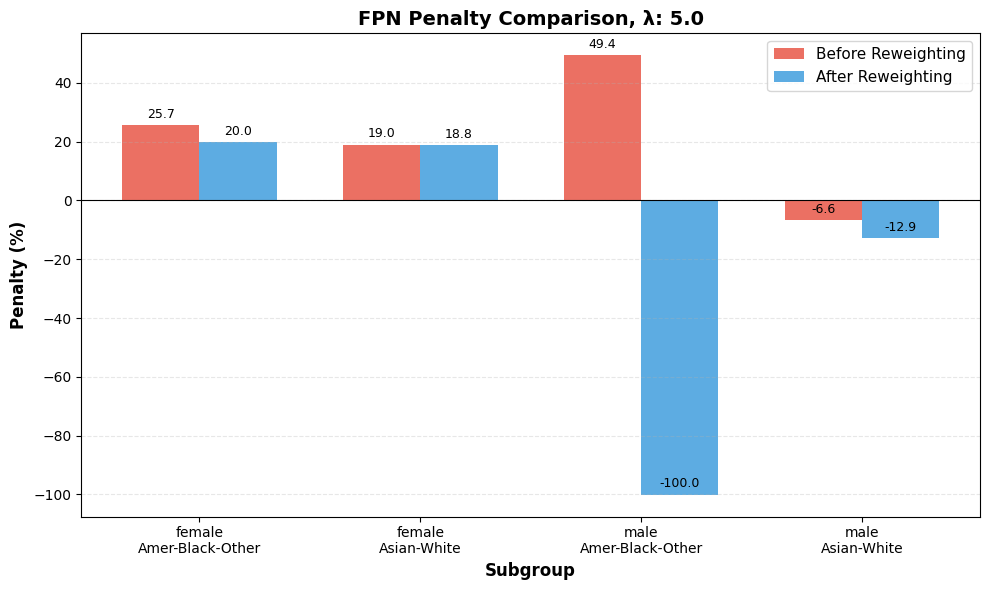


FPN - Penalty Changes:
  female-Amer-Black-Other: 25.71 → 19.97 (Δ = -5.74)
  female-Asian-White: 18.99 → 18.78 (Δ = -0.21)
  male-Amer-Black-Other: 49.35 → -100.04 (Δ = -149.40)
  male-Asian-White: -6.60 → -12.92 (Δ = -6.32)
------------------------------------------------------------


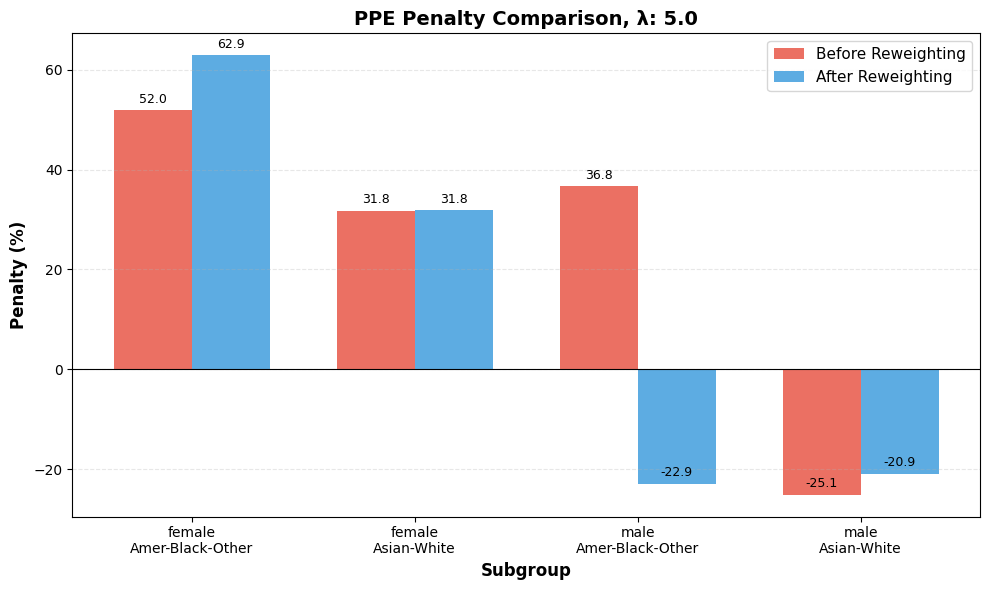


PPE - Penalty Changes:
  female-Amer-Black-Other: 51.99 → 62.90 (Δ = +10.92)
  female-Asian-White: 31.78 → 31.84 (Δ = +0.06)
  male-Amer-Black-Other: 36.76 → -22.91 (Δ = -59.68)
  male-Asian-White: -25.11 → -20.90 (Δ = +4.20)
------------------------------------------------------------


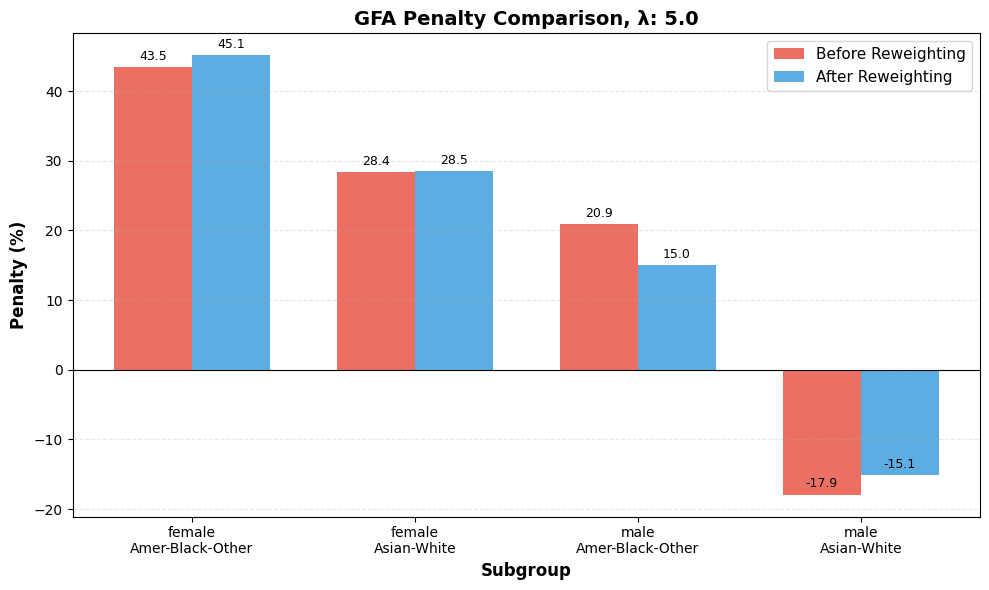


GFA - Penalty Changes:
  female-Amer-Black-Other: 43.46 → 45.14 (Δ = +1.69)
  female-Asian-White: 28.41 → 28.49 (Δ = +0.09)
  male-Amer-Black-Other: 20.95 → 15.00 (Δ = -5.94)
  male-Asian-White: -17.91 → -15.10 (Δ = +2.81)
------------------------------------------------------------


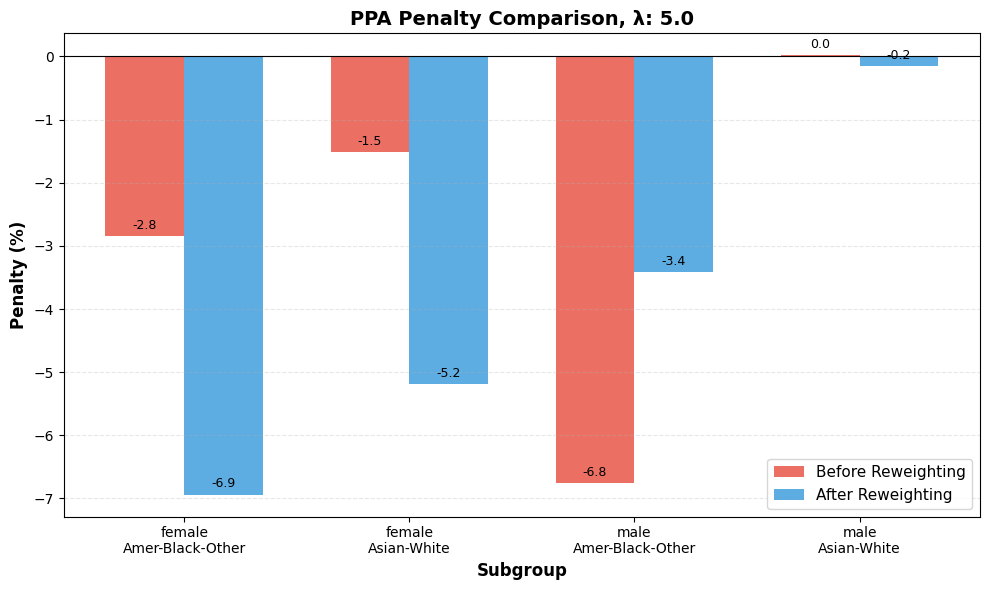


PPA - Penalty Changes:
  female-Amer-Black-Other: -2.84 → -6.94 (Δ = -4.10)
  female-Asian-White: -1.52 → -5.18 (Δ = -3.66)
  male-Amer-Black-Other: -6.75 → -3.41 (Δ = +3.34)
  male-Asian-White: 0.02 → -0.15 (Δ = -0.17)
------------------------------------------------------------


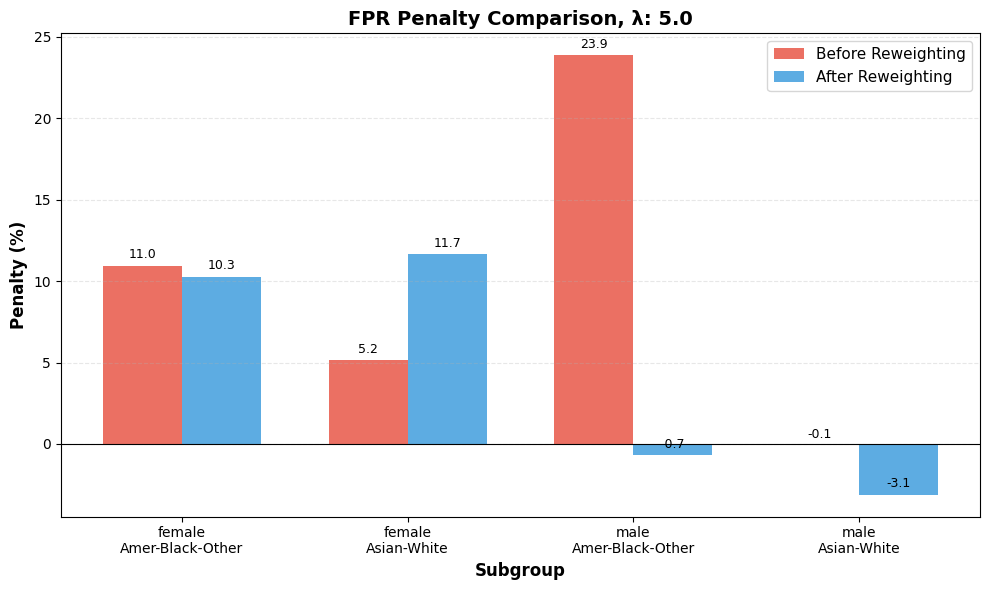


FPR - Penalty Changes:
  female-Amer-Black-Other: 10.95 → 10.28 (Δ = -0.67)
  female-Asian-White: 5.16 → 11.66 (Δ = +6.50)
  male-Amer-Black-Other: 23.87 → -0.70 (Δ = -24.58)
  male-Asian-White: -0.06 → -3.11 (Δ = -3.05)
------------------------------------------------------------


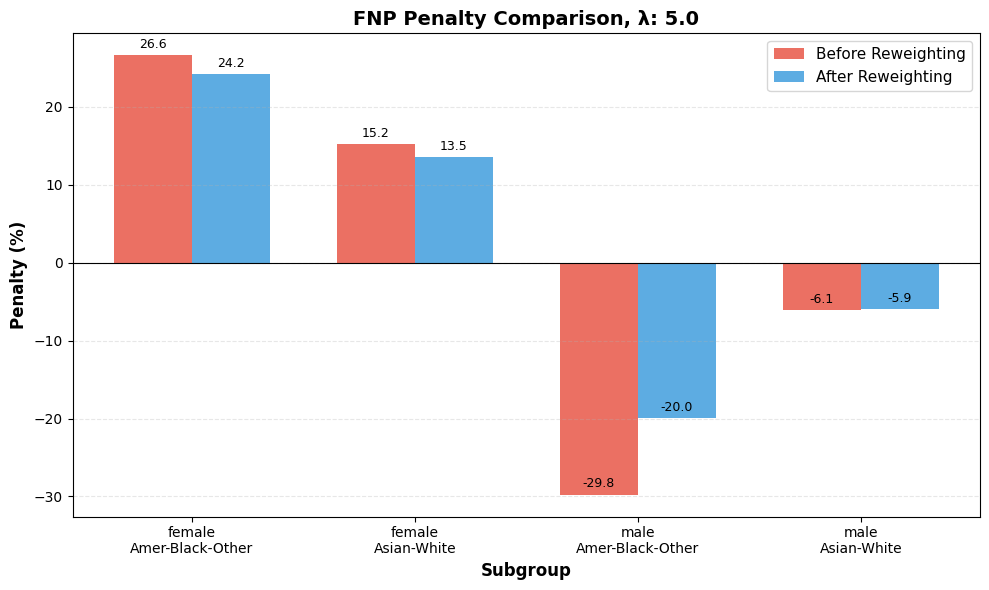


FNP - Penalty Changes:
  female-Amer-Black-Other: 26.63 → 24.22 (Δ = -2.40)
  female-Asian-White: 15.21 → 13.52 (Δ = -1.69)
  male-Amer-Black-Other: -29.76 → -19.97 (Δ = +9.79)
  male-Asian-White: -6.12 → -5.94 (Δ = +0.19)
------------------------------------------------------------


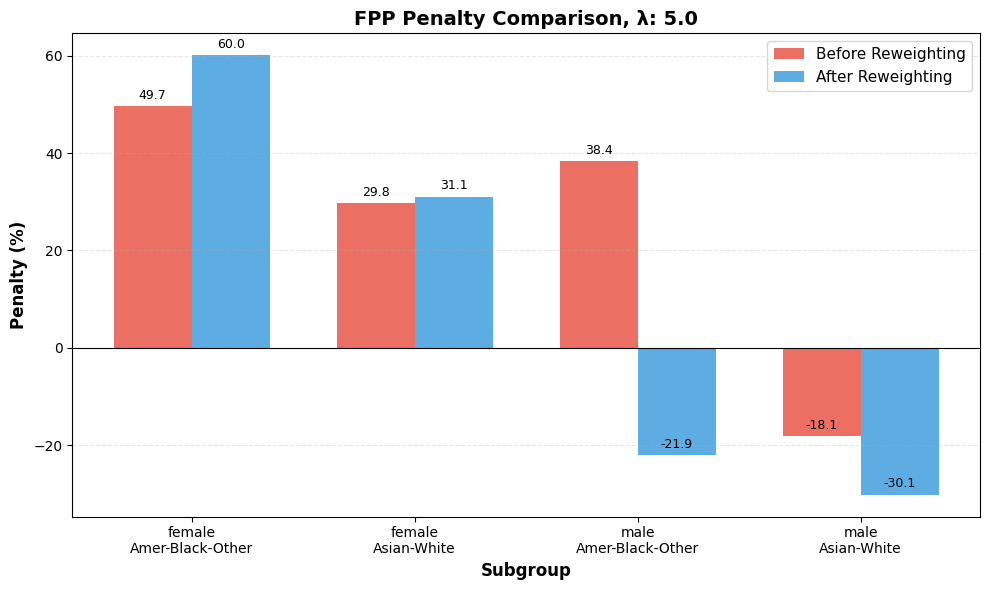


FPP - Penalty Changes:
  female-Amer-Black-Other: 49.68 → 60.05 (Δ = +10.37)
  female-Asian-White: 29.79 → 31.05 (Δ = +1.26)
  male-Amer-Black-Other: 38.36 → -21.94 (Δ = -60.30)
  male-Asian-White: -18.05 → -30.08 (Δ = -12.02)
------------------------------------------------------------
Training samples: 22792, Unique weights per group: {'00': 0.2563794422920551, '01': 2.1990431308577083, '10': 1.4179876712700645, '11': 0.49321238464203554}
{np.int64(0): array([[1408,   22],
       [  88,   92]]), np.int64(1): array([[2044,  205],
       [ 331,  695]])}
{np.int64(1): array([[2965,  220],
       [ 374,  756]]), np.int64(0): array([[487,   7],
       [ 45,  31]])}
{'01': array([[1146,   20],
       [  76,   81]]), '00': array([[262,   2],
       [ 14,   9]]), '11': array([[1819,  200],
       [ 303,  670]]), '10': array([[217,  13],
       [ 20,  33]])}
Training samples: 22792, Unique weights per group: {'00': 1.1313624255402128, '01': 2.6261656448923025, '10': 1.271957524858766, '11': 

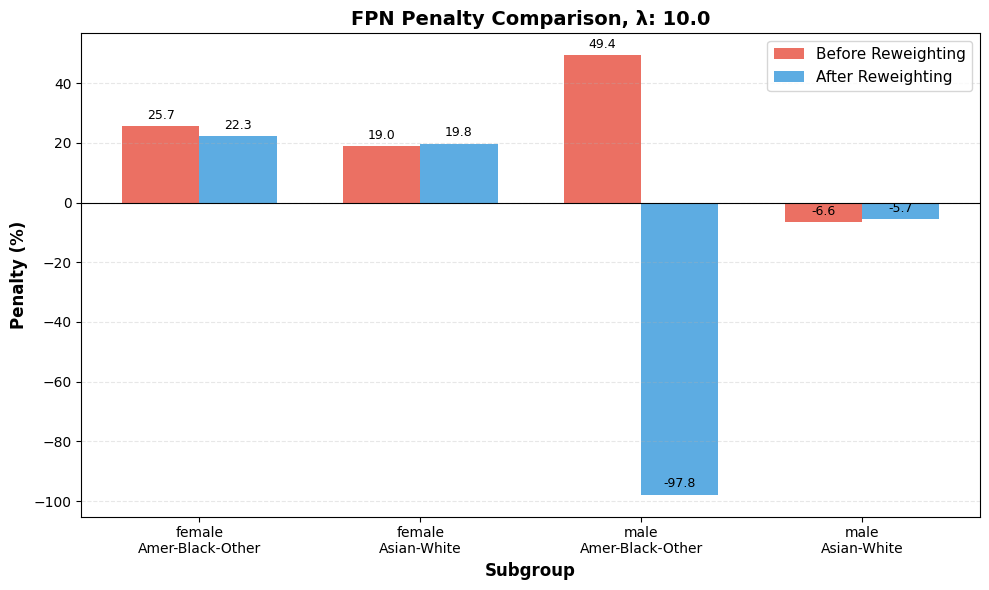


FPN - Penalty Changes:
  female-Amer-Black-Other: 25.71 → 22.32 (Δ = -3.39)
  female-Asian-White: 18.99 → 19.79 (Δ = +0.80)
  male-Amer-Black-Other: 49.35 → -97.82 (Δ = -147.17)
  male-Asian-White: -6.60 → -5.66 (Δ = +0.95)
------------------------------------------------------------


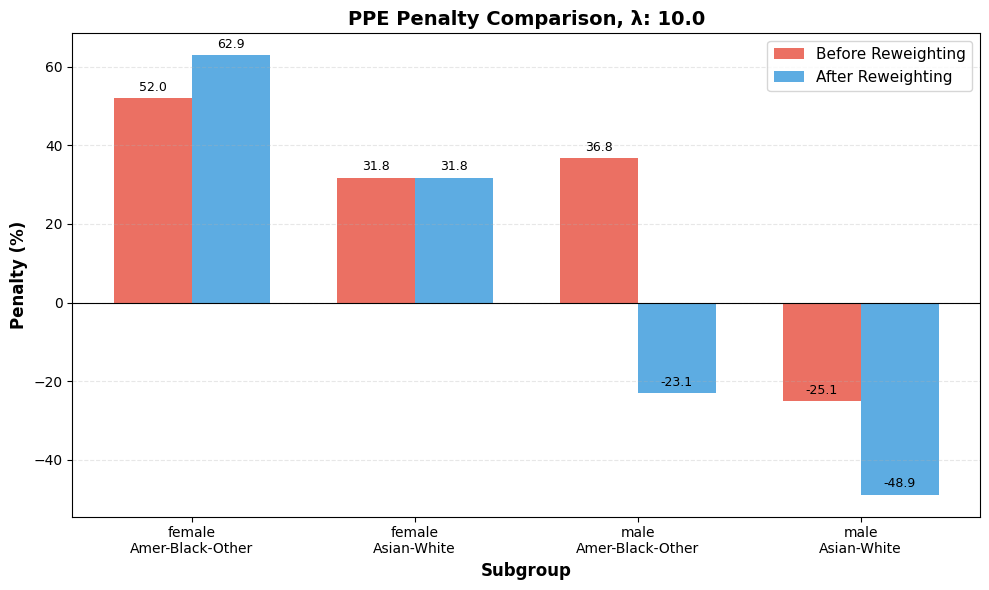


PPE - Penalty Changes:
  female-Amer-Black-Other: 51.99 → 62.90 (Δ = +10.92)
  female-Asian-White: 31.78 → 31.78 (Δ = +0.00)
  male-Amer-Black-Other: 36.76 → -23.05 (Δ = -59.82)
  male-Asian-White: -25.11 → -48.87 (Δ = -23.76)
------------------------------------------------------------


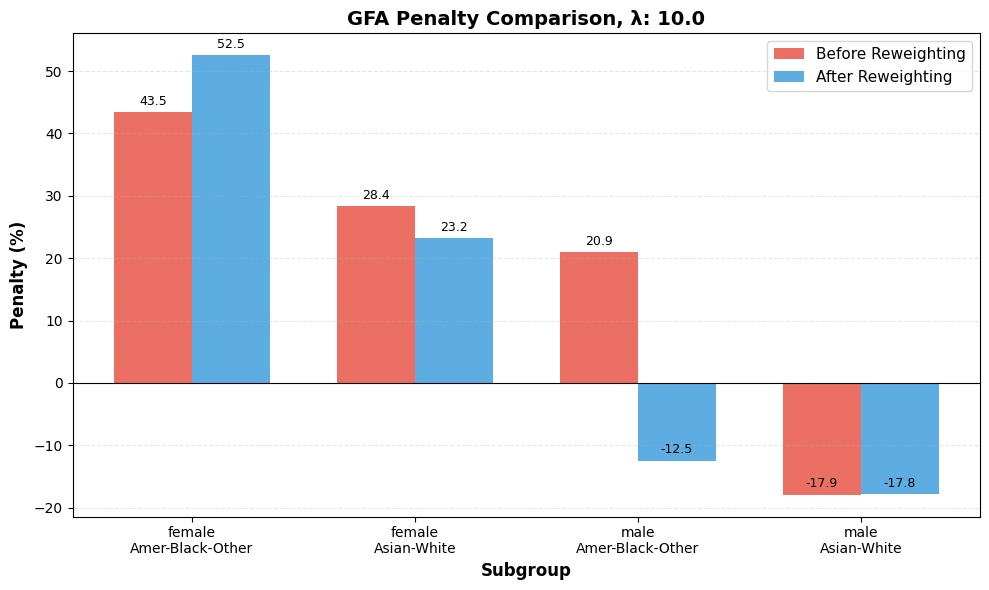


GFA - Penalty Changes:
  female-Amer-Black-Other: 43.46 → 52.53 (Δ = +9.07)
  female-Asian-White: 28.41 → 23.20 (Δ = -5.20)
  male-Amer-Black-Other: 20.95 → -12.48 (Δ = -33.42)
  male-Asian-White: -17.91 → -17.80 (Δ = +0.11)
------------------------------------------------------------


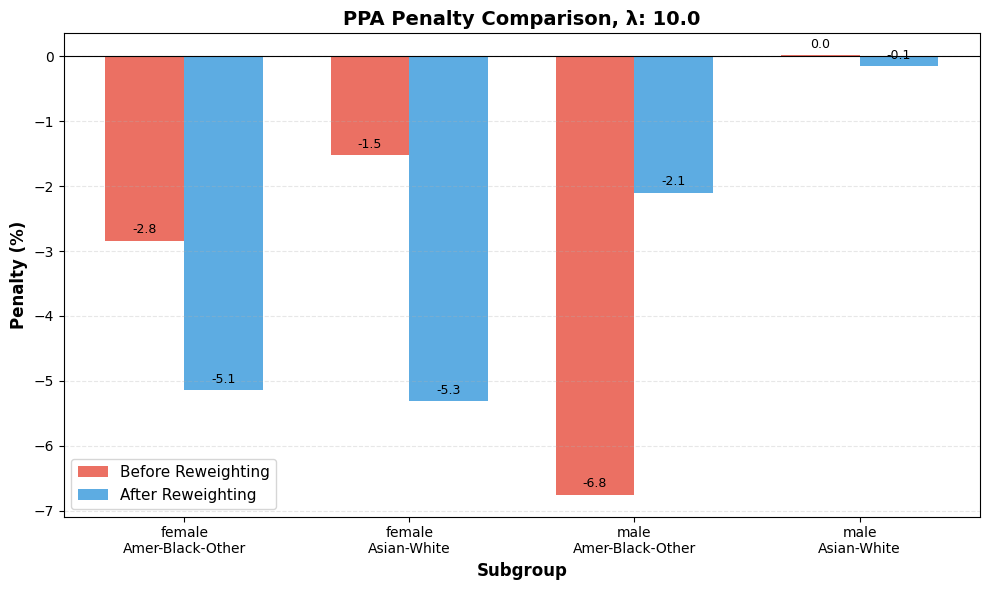


PPA - Penalty Changes:
  female-Amer-Black-Other: -2.84 → -5.14 (Δ = -2.30)
  female-Asian-White: -1.52 → -5.31 (Δ = -3.79)
  male-Amer-Black-Other: -6.75 → -2.10 (Δ = +4.65)
  male-Asian-White: 0.02 → -0.15 (Δ = -0.16)
------------------------------------------------------------


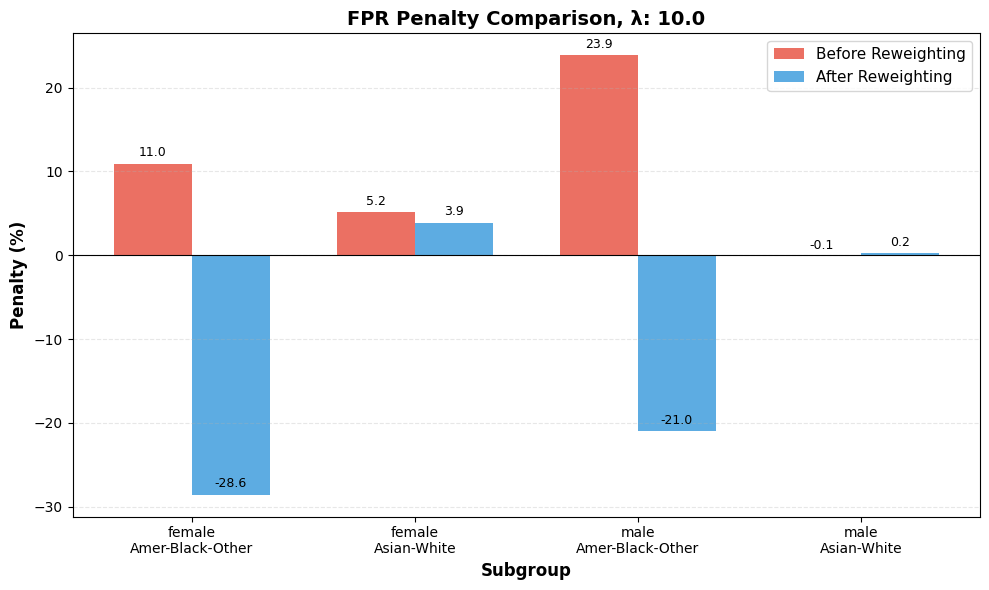


FPR - Penalty Changes:
  female-Amer-Black-Other: 10.95 → -28.57 (Δ = -39.52)
  female-Asian-White: 5.16 → 3.90 (Δ = -1.27)
  male-Amer-Black-Other: 23.87 → -21.01 (Δ = -44.88)
  male-Asian-White: -0.06 → 0.23 (Δ = +0.29)
------------------------------------------------------------


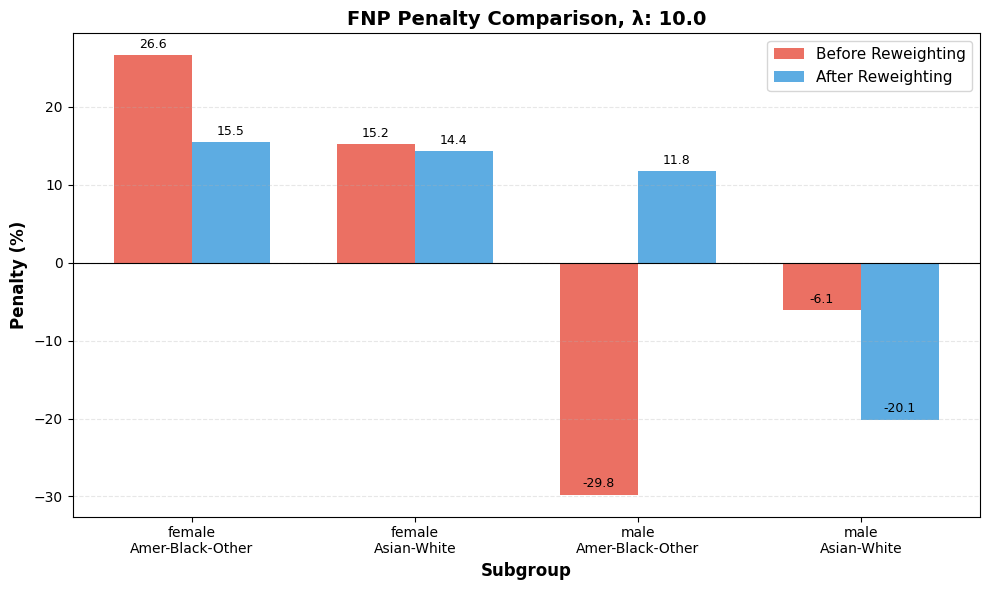


FNP - Penalty Changes:
  female-Amer-Black-Other: 26.63 → 15.48 (Δ = -11.15)
  female-Asian-White: 15.21 → 14.38 (Δ = -0.82)
  male-Amer-Black-Other: -29.76 → 11.76 (Δ = +41.52)
  male-Asian-White: -6.12 → -20.14 (Δ = -14.01)
------------------------------------------------------------


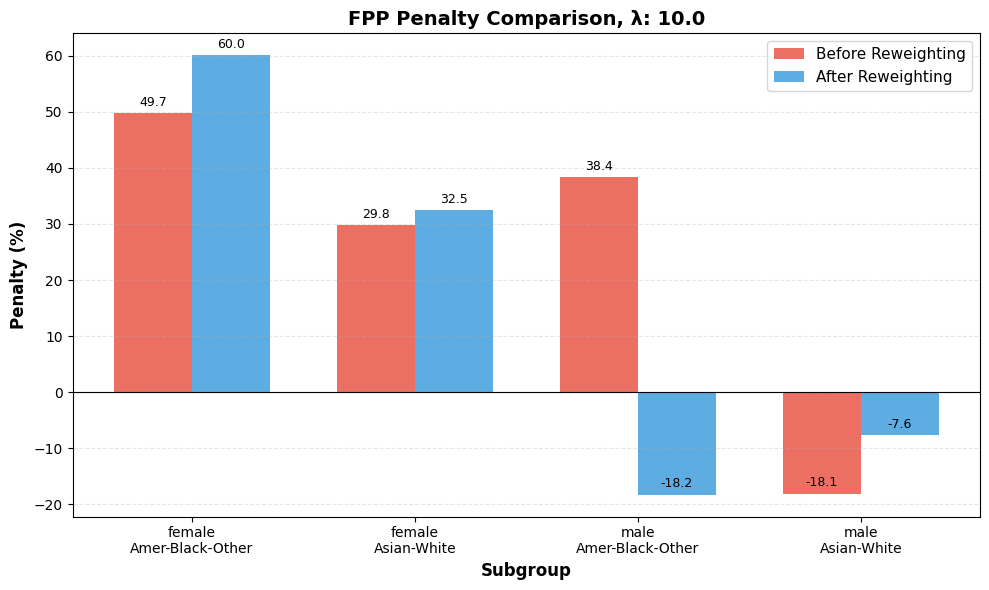


FPP - Penalty Changes:
  female-Amer-Black-Other: 49.68 → 60.05 (Δ = +10.37)
  female-Asian-White: 29.79 → 32.50 (Δ = +2.71)
  male-Amer-Black-Other: 38.36 → -18.23 (Δ = -56.59)
  male-Asian-White: -18.05 → -7.60 (Δ = +10.46)
------------------------------------------------------------


In [ ]:
if SIZED == 1:
    for l in lambdas:
        penalties_ontest_after_reweighting = {}

        for metric in fair_metrics:
            # print("FAIRNESS METRIC:", metric)
            weights_sized = compute_weights_sized(l, metric, penalties_onval, X_train, sensible_attribute)
            penalties_ontest_after_reweighting[metric]= compute_penalties_after_reweighting(weights_sized, metric, dataset_path, sensible_attribute, X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels) # Get only harmonic penalty
            # print("\n")

        plot_penalty_comparison_all_individual(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, 
                                                sensible_attribute, mapping, l)

In [ ]:
if SIZED == 1 and ALL_FM_L_SIZED == 1:
    for l in lambdas:
        penalties_ontest_after_reweighting = {}

        for metric in fair_metrics:
            # print("FAIRNESS METRIC:", metric)
            weights_sized = compute_weights_sized(l, metric, penalties_onval, X_train, sensible_attribute)
            penalties_ontest_after_reweighting[metric]= compute_penalties_after_reweighting(weights_sized, metric, dataset_path, sensible_attribute, X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels) # Get only harmonic penalty
            # print("\n")

        plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, 
                                                sensible_attribute, mapping, l)

Training samples: 22792, Unique weights per group: {'00': 0.5854166666666667, '01': 1.1334418968212612, '10': 1.2170608108108107, '11': 0.9746606192321018}
{np.int64(0): array([[1408,   22],
       [  88,   92]]), np.int64(1): array([[2047,  202],
       [ 334,  692]])}
{np.int64(1): array([[2967,  218],
       [ 376,  754]]), np.int64(0): array([[488,   6],
       [ 46,  30]])}
{'01': array([[1136,   30],
       [  71,   86]]), '00': array([[262,   2],
       [ 14,   9]]), '11': array([[1812,  207],
       [ 286,  687]]), '10': array([[225,   5],
       [ 33,  20]])}
Training samples: 22792, Unique weights per group: {'00': 0.17083333333333328, '01': 1.2668837936425221, '10': 1.4341216216216215, '11': 0.9493212384642036}
{np.int64(0): array([[1408,   22],
       [  91,   89]]), np.int64(1): array([[2045,  204],
       [ 332,  694]])}
{np.int64(1): array([[2965,  220],
       [ 376,  754]]), np.int64(0): array([[488,   6],
       [ 47,  29]])}
{'01': array([[1146,   20],
       [  76, 

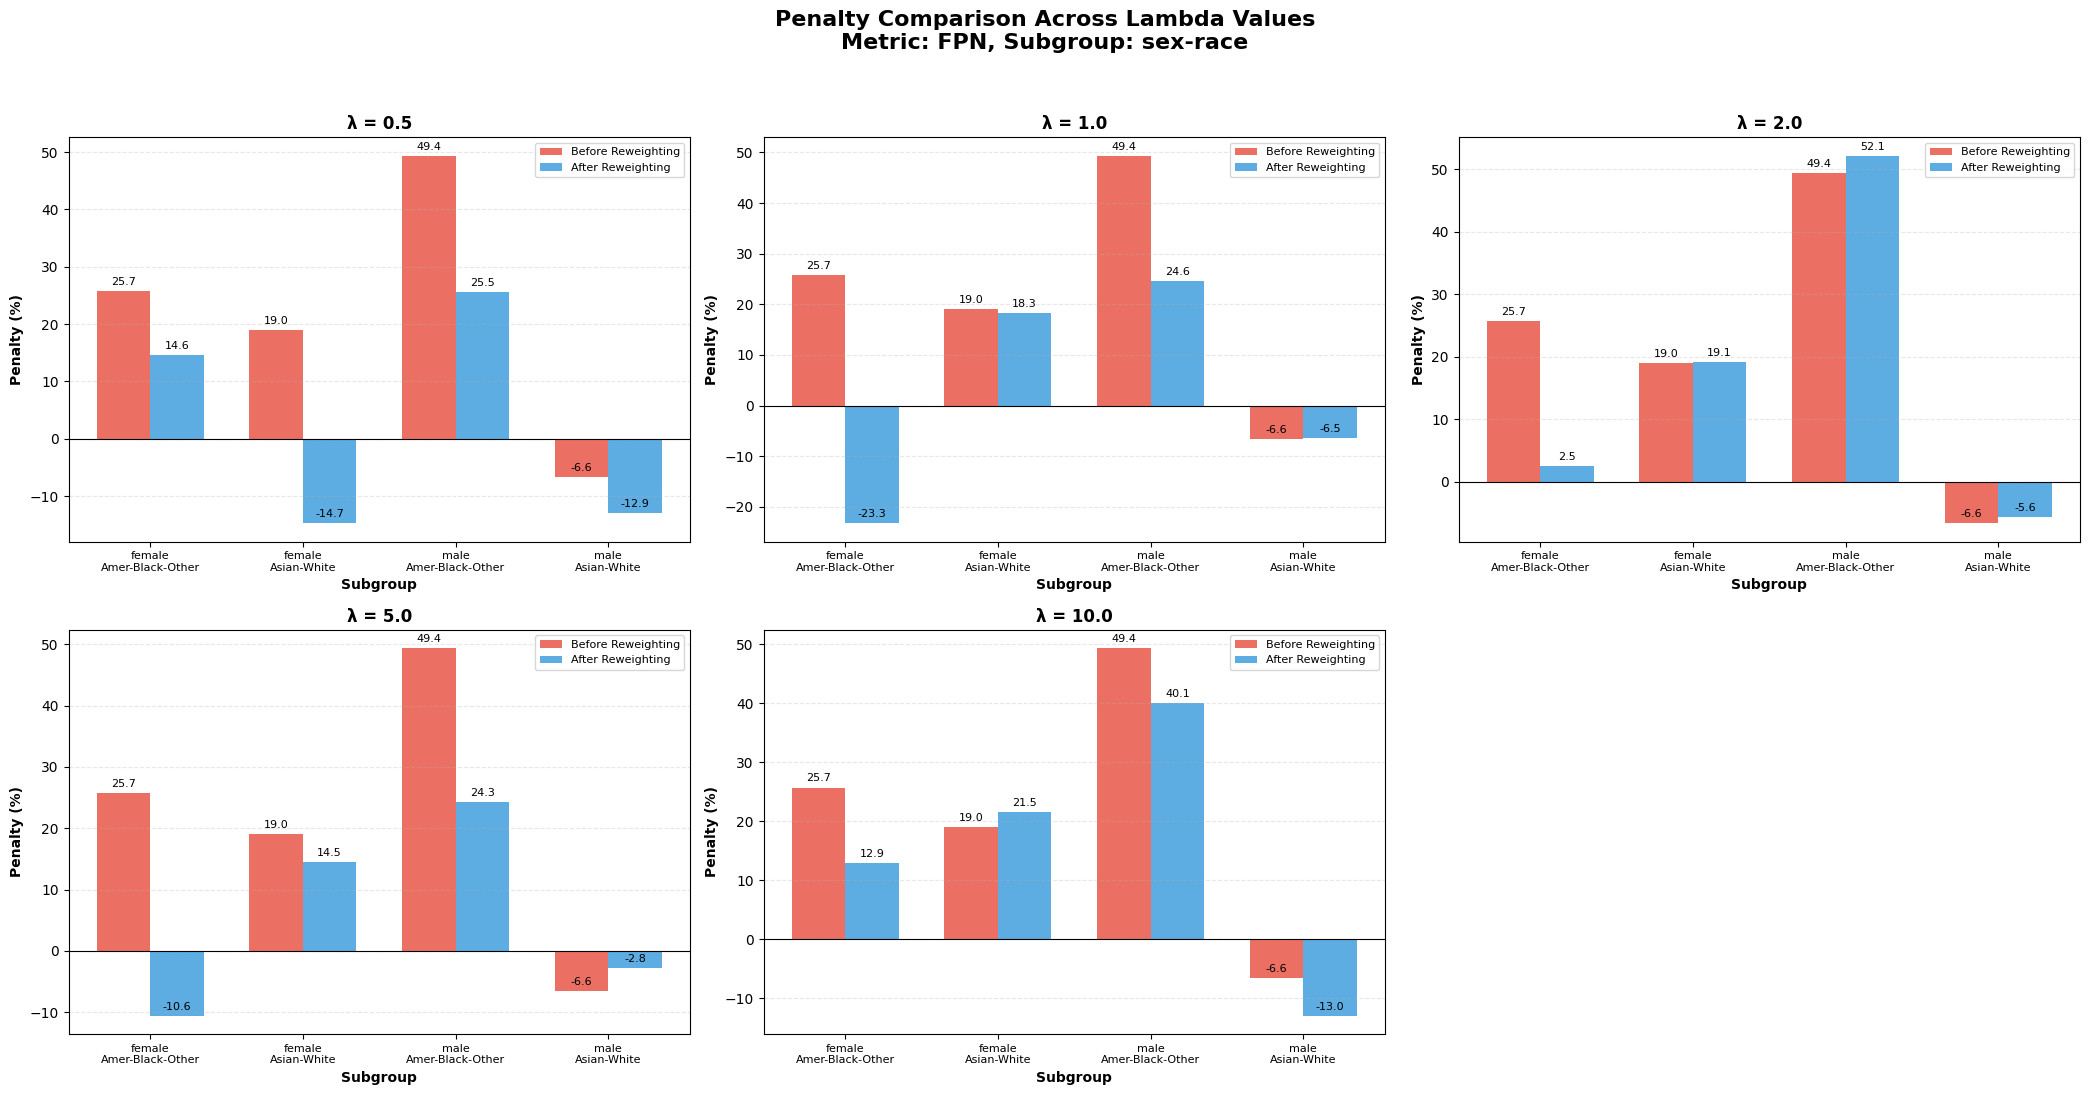

In [ ]:
# First, compute penalties for each lambda
penalties_after_by_lambda = {}
lambdas = [0.5, 1.0, 2.0, 5.0, 10.0]

for lambd in lambdas:
    penalties_ontest_after_reweighting = {}
    weights_notsized = compute_weights_notsized(lambd, 'FPN', penalties_onval, X_train, sensible_attribute)
    penalties_ontest_after_reweighting['FPN'] = compute_penalties_after_reweighting(
        weights_notsized, 'FPN', dataset_path, sensible_attribute, 
        X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels
    )
    penalties_after_by_lambda[lambd] = penalties_ontest_after_reweighting

# Then plot
plot_penalty_comparison_lambdas('FPN', lambdas, penalties_ontest, penalties_after_by_lambda, 
                                sensible_attribute, mapping)

Training samples: 22792, Unique weights per group: {'00': 0.9628189721146028, '01': 1.0599521565428853, '10': 1.0208993835635032, '11': 0.9746606192321018}
{np.int64(0): array([[1407,   23],
       [  88,   92]]), np.int64(1): array([[2046,  203],
       [ 331,  695]])}
{np.int64(1): array([[2967,  218],
       [ 373,  757]]), np.int64(0): array([[486,   8],
       [ 46,  30]])}
{'01': array([[1146,   20],
       [  77,   80]]), '00': array([[262,   2],
       [ 14,   9]]), '11': array([[1824,  195],
       [ 304,  669]]), '10': array([[225,   5],
       [ 32,  21]])}
Training samples: 22792, Unique weights per group: {'00': 0.9256379442292055, '01': 1.1199043130857709, '10': 1.0417987671270064, '11': 0.9493212384642036}
{np.int64(0): array([[1408,   22],
       [  92,   88]]), np.int64(1): array([[2048,  201],
       [ 336,  690]])}
{np.int64(1): array([[2969,  216],
       [ 382,  748]]), np.int64(0): array([[487,   7],
       [ 46,  30]])}
{'01': array([[1135,   31],
       [  70,  

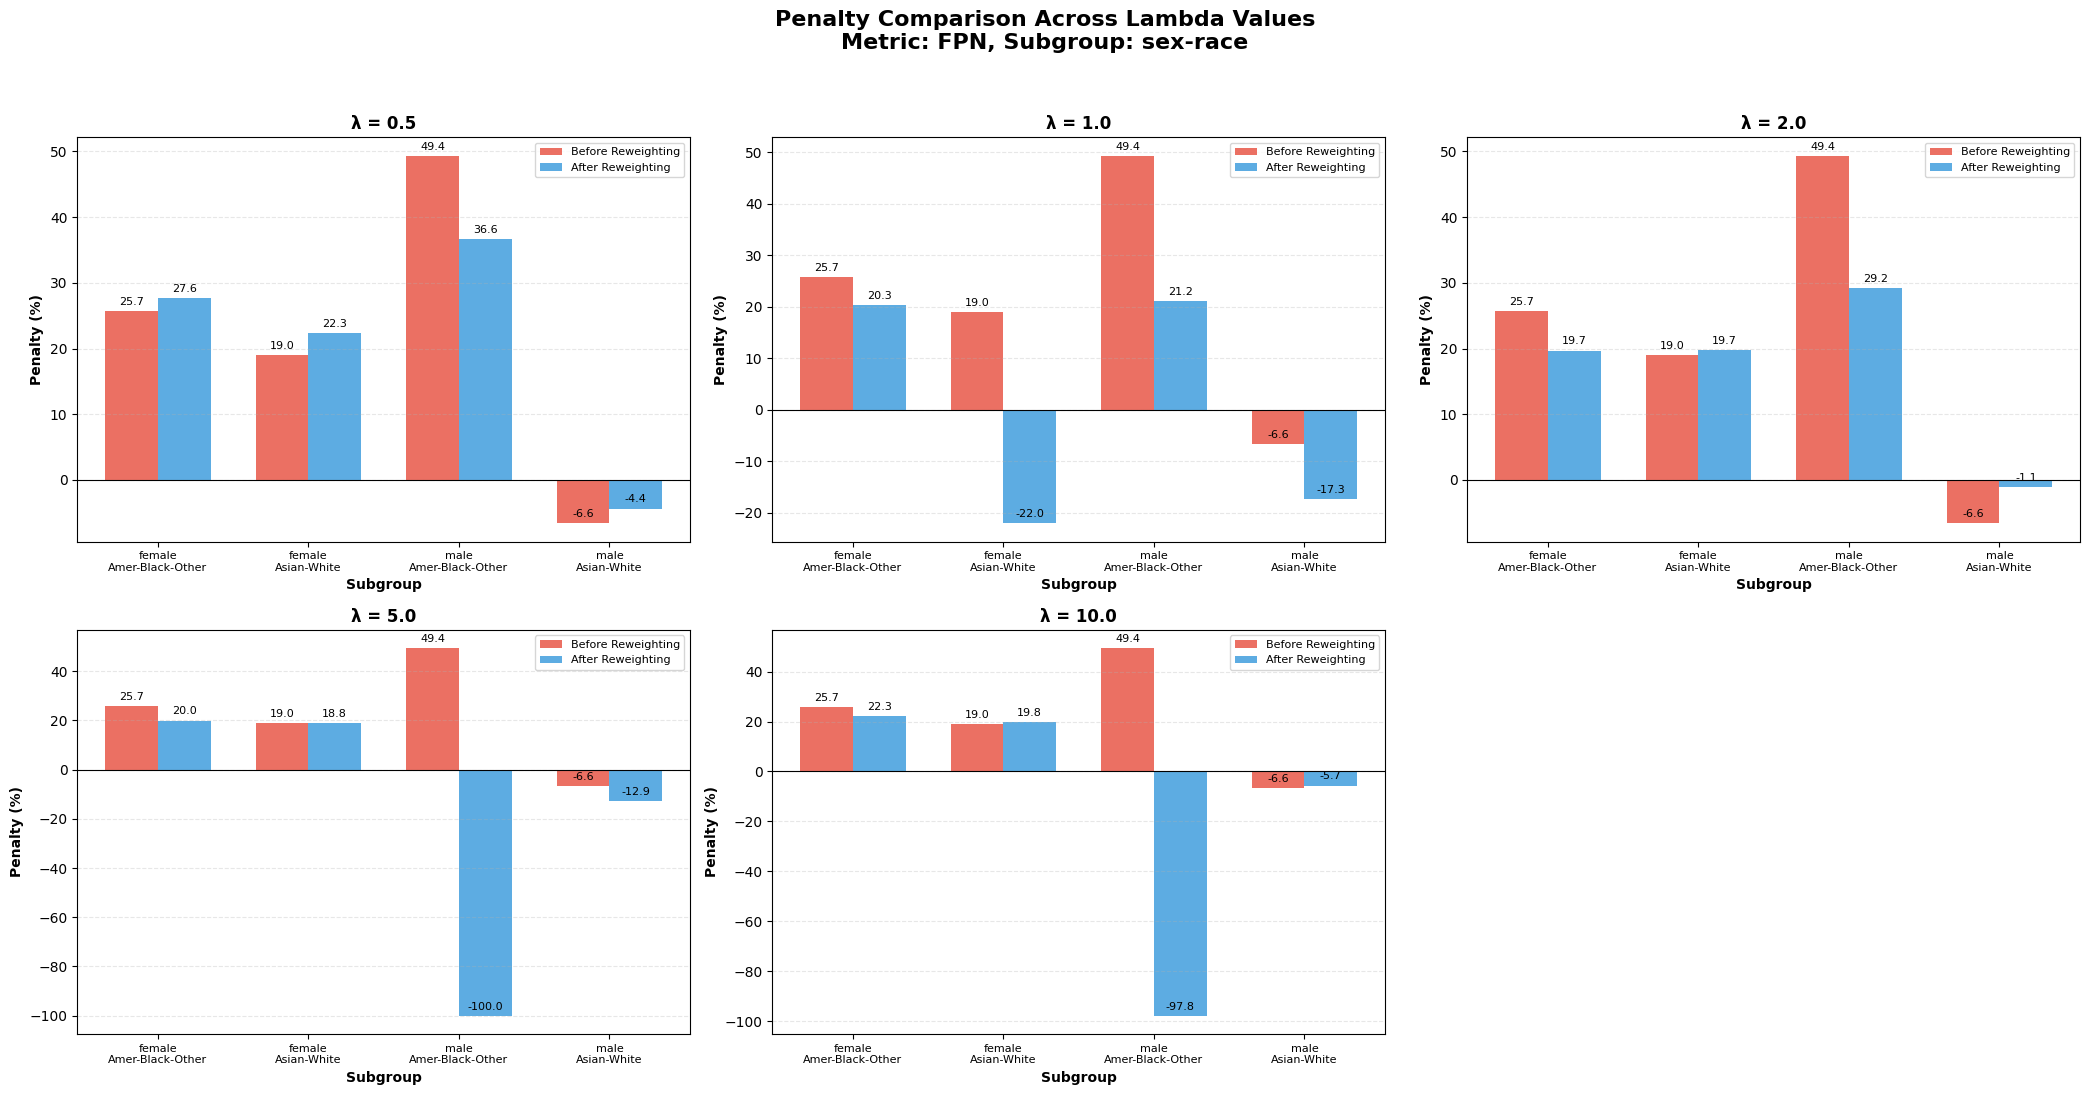

In [ ]:
# First, compute penalties for each lambda
penalties_after_by_lambda = {}
lambdas = [0.5, 1.0, 2.0, 5.0, 10.0]

for lambd in lambdas:
    penalties_ontest_after_reweighting = {}
    weights_notsized = compute_weights_sized(lambd, 'FPN', penalties_onval, X_train, sensible_attribute)
    penalties_ontest_after_reweighting['FPN'] = compute_penalties_after_reweighting(
        weights_notsized, 'FPN', dataset_path, sensible_attribute, 
        X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels
    )
    penalties_after_by_lambda[lambd] = penalties_ontest_after_reweighting

# Then plot
plot_penalty_comparison_lambdas('FPN', lambdas, penalties_ontest, penalties_after_by_lambda, 
                                sensible_attribute, mapping)